# 웹 사용자 행동 분석 및 고객 세분화
- 주제: Customer Intelligence(웹사이트 사용자 행동 분석 및 고객 세분화)
    - 전자상거래 웹사이트의 사용자 로그 데이터를 기반으로 고객 행동 패턴을 분석하고, 장기적인 전략을 위한 고객 세그먼트 구축
- 목표: 고객의 장기적인 행동과 성향을 정량화한 지표(Tag)를 개발하여 맞춤형 마케팅 전략을 수립하기 위한 고객 세분화 및 행동 지표 개발

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

file_path = 'c:/pythondata/E-commerce Website Logs.csv'
df = pd.read_csv(file_path, low_memory=False)  # Columns (6) have mixed types 경고메세지 방지로 인해 옵션 추가

In [2]:
df.head()

,accessed_date,duration_(secs),network_protocol,ip,bytes,accessed_Ffom,age,gender,country,membership,language,sales,returned,returned_amount,pay_method
0,2017-03-14 17:43,2533,TCP,1.10.195.126,20100,Chrome,28,Female,CA,Normal,English,261.9600,No,0.0,Credit Card
1,2017-03-14 17:43,4034,TCP,1.1.217.211,20500,Mozilla Firefox,21,Male,AR,Normal,English,731.9400,No,0.0,Debit Card
2,2017-03-14 17:43,1525,TCP,1.115.198.107,90100,Mozilla Firefox,20,Male,PL,Normal,English,14.6200,No,0.0,Cash
3,2017-03-14 17:43,4572,TCP,1.121.152.143,100300,Mozilla Firefox,66,Female,IN,Normal,Spanish,957.5775,No,0.0,Credit Card
4,2017-03-14 18:17,3652,TCP,1.123.135.213,270200,Mozilla Firefox,53,Female,KR,Normal,Spanish,22.3680,No,0.0,Cash


## 공통 전처리

### 결측치 처리
- age 변수의 결측값 및 잘못된 값(--)을 'Unknown'으로 대체
- 'Unknown'을 숫자(-1)로 변환하여 나중에 분석 및 처리가 용이하도록 함
- accessed_date는 datetime 형식으로 변환하여 시간 관련 분석 가능

In [3]:
# age 변수 결측치 처리: 'Unknown'으로 대체 후 숫자로 변환
df['age'] = df['age'].replace('--', 'Unknown')  # '--' 값을 'Unknown'으로 대체
df['age'] = df['age'].fillna('Unknown')  # 결측값 처리
df['age'] = pd.to_numeric(df['age'], errors='coerce')  # 숫자로 변환 가능하면 변환, 안되면 NaN
df['age'] = df['age'].fillna(-1)  # 숫자로 변환되지 않는 'Unknown'은 -1로 대체

# accessed_date 변수 처리: 날짜 형식으로 변환
df['accessed_date'] = pd.to_datetime(df['accessed_date'])  # datetime 형식으로 변환

### 텍스트 데이터 정리
- 범주형 데이터(network_protocol, accessed_From, language)의 오타를 수정하고, 대소문자를 통일하여 데이터의 일관성 확보

In [4]:
# network_protocol 정리: 공백 제거 및 대문자로 통일
df['network_protocol'] = df['network_protocol'].str.strip().str.upper()

# accessed_From 오타 수정 및 대소문자 통일
df.rename(columns={'accessed_Ffom': 'accessed_From'}, inplace=True)  # 컬럼 이름 수정
df['accessed_From'] = df['accessed_From'].replace({'SafFRi': 'Safari'})  # 오타 수정
df['accessed_From'] = df['accessed_From'].str.capitalize()  # 대소문자 통일

# language 변수 중복 제거 및 대소문자 통일
df['language'] = df['language'].str.capitalize()

### 데이터 정렬
- 고객 행동 흐름을 시간순으로 분석하기 위해 ip와 accessed_date를 기준으로 데이터 정렬

In [5]:
# ip와 accessed_date 기준으로 데이터 정렬
df = df.sort_values(by=['ip', 'accessed_date'])

### 세션 변수 생성
- 1시간 이상 공백이 있거나 IP가 변경되면 새로운 세션으로 간주하여 session_id 생성

In [6]:
# 세션 변수 생성
df['time_diff'] = df['accessed_date'].diff().dt.total_seconds().fillna(0)  # 이전 행과의 시간 차이 계산
df['new_session'] = (df['time_diff'] > 3600) | (df['ip'] != df['ip'].shift())  # 1시간 초과 또는 IP 변경 시 새로운 세션
df['session_id'] = df['new_session'].cumsum()  # 누적합으로 세션 ID 생성

### 불필요 변수 제거
- 중복 데이터를 제거하여 분석 성능 및 데이터 간소화
- 로그성 변수(e.g. network_protocol)는 제거

In [7]:
# 중복 데이터 제거
df = df.drop_duplicates()  # 완전 중복된 행 제거

# 분석에 불필요한 로그성 변수 제거
columns_to_drop = ['network_protocol', 'some_other_log_variables']  # 필요 없는 컬럼 리스트
df = df.drop(columns=columns_to_drop, errors='ignore')

### 범주형 변수 인코딩
- 머신러닝 모델에 활용할 수 있도록 범주형 변수를 인코딩
    - accessed_From: One-Hot Encoding
    - membership: Label Encoding
- 인코딩 후에 플랫폼 유형별 그룹화 시도

In [8]:
from sklearn.preprocessing import LabelEncoder

# 범주형 변수 인코딩
df = pd.get_dummies(df, columns=['accessed_From'], drop_first=True)  # One-Hot Encoding
le = LabelEncoder()
df['membership'] = le.fit_transform(df['membership'])  # Label Encoding

In [9]:
# 플랫폼 유형별 그룹화
# df는 이미 접근 방법에 대해 원핫 인코딩이 완료된 상태라고 가정
df['Desktop'] = df['accessed_From_Chrome'] + df['accessed_From_Microsoft edge'] + df['accessed_From_Mozilla firefox']
df['Mobile'] = df['accessed_From_Ios app'] + df['accessed_From_Safari']
df['Other'] = df['accessed_From_Others']

conditions = [
    df['Desktop'] > 0,
    df['Mobile'] > 0,
    df['Other'] > 0
]
choices = ['Desktop', 'Mobile', 'Other']
df['platform_type'] = np.select(conditions, choices, default='Unknown')

### 나잇대 범주화
- age 데이터를 그룹화하여 범주형 변수로 변환

In [10]:
# 나이를 범주화하기 전에 결측값을 'Unknown'으로 설정
df['age_group'] = pd.cut(df['age'], bins=[18, 30, 40, 50, 60, 70], labels=['18-30', '30-40', '40-50', '50-60', '60-70'], right=False)
df['age_group'] = df['age_group'].cat.add_categories('Unknown').fillna('Unknown')

# 결과 확인
print(df[['age', 'age_group']].head())

        age age_group
1      21.0     18-30
19927  65.0     60-70
39853  -1.0   Unknown
59779  29.0     18-30
79705  29.0     18-30


In [11]:
# age_group이 'unknown'인 행만 필터링 -> 행의 개수 계산
unknown_rows = df[df['age_group']=='Unknown'].shape[0]

print('행 전체 개수: ',len(df))
print('age_group이 Unknown인 행의 개수: ', unknown_rows)

행 전체 개수:  172838
age_group이 Unknown인 행의 개수:  88124


- age_group의 결측치가 약 50% 가까이 해당하므로 heatmap, box-plot 등을 활용해 특정 변수들 간의 관계 살펴보기
    - age_group의 Unknown과 그렇지 않은 경우가 다른 변수와 어떤 관계가 있는지 시각적으로 파악하기
- 특정한 패턴이 보이지 않는다면 Unknown 값 자체로 의미가 있을 수 있음(개인 정보 보호 등의 이유로) -> 별도의 범주로 남겨두기(Missing Not At Random)

C:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47605 (\N{HANGUL SYLLABLE MAEB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 5083

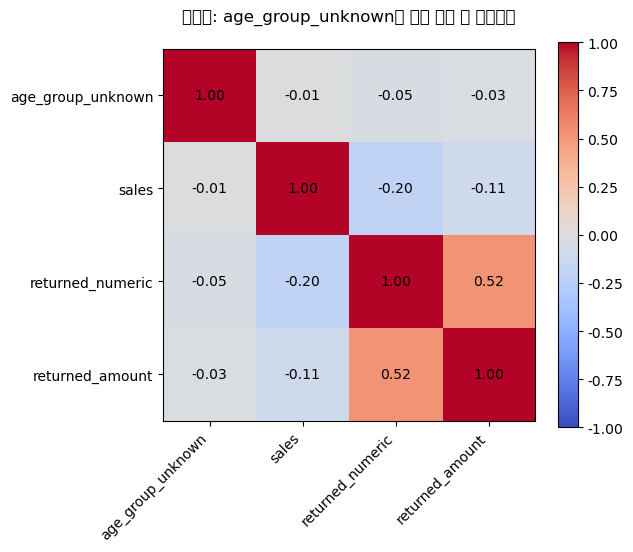

In [12]:
#1. 히트맵을 통한 상관관계 분석
# 1-1) 'age_group'이 Unknown인 경우를 1, 아니면 0인 이진 컬럼
df['age_group_unknown'] = (df['age_group']=='Unknown').astype(int)

# 1-2) 'returned'컬럼을 이진형 변수로 변환(Yes:1, No:0)
df['returned_numeric'] = df['returned'].map({'Yes':1, 'No':0})

# 1-3) 분석할 컬럼 'sales', 'returned_numeric', 'returned_amount'
cols_to_analyze = ['age_group_unknown', 'sales', 'returned_numeric', 'returned_amount']

# 1-4) 선택한 컬럼들의 상관관계
corr_matrix = df[cols_to_analyze].corr()

# 히트맵 생성
fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# 컬러바 추가
fig.colorbar(cax)

# 1-6) 축 레이블 설정
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticklabels(corr_matrix.columns)

# x축 라벨 기울기 45도 수정
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# 각 셀 안에 상관계수 값 텍스트로 표시
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        value = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.2f}",
                ha="center", va="center", color="black")

# (선택) minus 폰트 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

plt.title("히트맵: age_group_unknown과 주요 변수 간 상관관계", pad=20)
plt.show()

- age_group_unknown과 다른 변수 sales, returned, returned_amount 간 유의미한 상관관계가 거의 없다(+/- 0.1 미만)
- 다만, 상관관계는 선형적 관계만을 반영하기 때문에, 비선형 관계가 존재할 가능성도 있음.

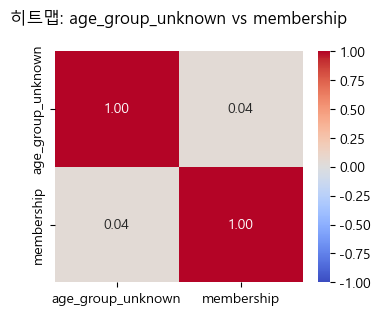

In [13]:
# membership컬럼 간 상관관계
#1. 상관관계 계산
corr_matrix = df[['age_group_unknown', 'membership']].corr()

#2. 히트맵 시각화
plt.figure(figsize=(4, 3))
sns.heatmap(corr_matrix,
            annot=True,   # 셀 안에 상관계수 표시
            fmt=".2f",
            cmap='coolwarm',
            vmin=-1, vmax=1)
plt.title("히트맵: age_group_unknown vs membership", pad=20)
plt.show()

- membership 컬럼과도 유의미한 상관관계 보이지 않음.

- age_group 중 Unknown의 비중이 매우 크고, 나이 정보가 없는 것 자체가 '개인정보 보호' 혹은 '비로그인 사용자'라는 의미 있는 특성을 가지는 것으로 판단되므로 아래의 이유로 **Unknown을 독립된 범주로 유지**하는 것을 우선적으로 고려한다.
    >1. 데이터 손실이 없음.
    >2. Unknown 자체가 하나의 고객군
    >3. 클러스터링(세분화) 시에도 '나이 정보가 없는 집단' 그대로 반영 가능

In [14]:
# # age_group_status 컬럼 삭제
# df.drop('age_group_status', axis=1, inplace=True)

In [15]:
# age_group_unknown과 다른 변수 간 통계적 검증 고려
## T-검정, Mann_Whitney U test

In [16]:
# age_group 원-핫 인코딩
age_group_dummies = pd.get_dummies(df['age_group'],prefix='age_group')
df = pd.concat([df, age_group_dummies], axis=1)

### 데이터 요약 확인
- 최종 전처리된 데이터를 확인하여 결과 점검

In [17]:
# 중복된 컬럼 제거
#df = df.loc[:, ~df.columns.duplicated()]

In [18]:
df.drop('age_group_unknown', axis=1, inplace=True)

In [19]:
# 데이터 요약 정보 확인
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 172838 entries, 1 to 169088
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   accessed_date                  172838 non-null  datetime64[ns]
 1   duration_(secs)                172838 non-null  int64         
 2   ip                             172838 non-null  object        
 3   bytes                          172838 non-null  int64         
 4   age                            172838 non-null  float64       
 5   gender                         172838 non-null  object        
 6   country                        172838 non-null  object        
 7   membership                     172838 non-null  int32         
 8   language                       172838 non-null  object        
 9   sales                          172838 non-null  float64       
 10  returned                       172838 non-null  object        
 11  retur

In [20]:
print(df.head())
print(df.columns)

            accessed_date  duration_(secs)           ip  bytes   age   gender  \
1     2017-03-14 17:43:00             4034  1.1.217.211  20500  21.0     Male   
19927 2017-03-15 23:12:00             2030  1.1.217.212     46  65.0   Female   
39853 2017-03-16 19:31:00             3673  1.1.217.213    264  -1.0  Unknown   
59779 2017-03-17 18:51:00             2028  1.1.217.214    467  29.0     Male   
79705 2017-03-18 11:36:00             4808  1.1.217.215     92  29.0   Female   

      country  membership language    sales  ...  Other  platform_type  \
1          AR           0  English   731.94  ...  False        Desktop   
19927      JP           2     Thai   600.16  ...  False        Desktop   
39853      IN           1     Thai     0.00  ...  False         Mobile   
59779      RU           2     Thai    81.32  ...  False        Unknown   
79705      US           2     Thai  1500.40  ...   True          Other   

      age_group  returned_numeric  age_group_18-30  age_group_30-40 

## 변수 선정 및 스케일링

**고객별 주요 지표 집계**  
- 기본
    1. 행동 및 소비 변수
        - duration_(secs), sales, returned_amount는 고객 행동 강도와 소비 패턴을 정량적으로 측정하여 군집화 가능
    2. 고객 특성 변수
        - membership은 고객 분류의 핵심요소로, 고객 특성 기반으로 군집화 가능
        - age_group 삭제
    3. 접속 기기
        - 플랫폼 별로 그룹화
        - Desktop, Mobile, Other
    4. 추가 파생변수 및 기존 변수 수정(📍0328)
        - 고매출 고객 high_spender = 1 if sales > threshold else 0 → 고매출 고객군 구분
    5. **최종 변수**
        - 최종 변수 선정 후 적어넣기

In [26]:
# 파생변수 추가
# high_spender: 로그 변환 후 상위 25% 기준
df['log_sales'] = np.log1p(df['sales'])
threshold = df['log_sales'].quantile(0.75)
df['high_spender'] = (df['log_sales'] >= threshold).astype(int)

# 원 컬럼 df에 device_* prefix 수정(📍0404 수정)
# 1. 대상 컬럼 정의
columns_to_change = ['Desktop', 'Mobile', 'Other']

# 2. 컬럼명에 'device_' prefix 붙이기
df.rename(columns={col: f'device_{col.lower()}' for col in columns_to_change}, inplace=True)

## 확인
df.head()

,accessed_date,duration_(secs),ip,bytes,age,gender,country,membership,language,sales,...,age_group,returned_numeric,age_group_18-30,age_group_30-40,age_group_40-50,age_group_50-60,age_group_60-70,age_group_Unknown,log_sales,high_spender
1,2017-03-14 17:43:00,4034,1.1.217.211,20500,21.0,Male,AR,0,English,731.94,...,18-30,0,True,False,False,False,False,False,6.597064,1
19927,2017-03-15 23:12:00,2030,1.1.217.212,46,65.0,Female,JP,2,Thai,600.16,...,60-70,0,False,False,False,False,True,False,6.398861,1
39853,2017-03-16 19:31:00,3673,1.1.217.213,264,-1.0,Unknown,IN,1,Thai,0.00,...,Unknown,0,False,False,False,False,False,True,0.000000,0
59779,2017-03-17 18:51:00,2028,1.1.217.214,467,29.0,Male,RU,2,Thai,81.32,...,18-30,0,True,False,False,False,False,False,4.410614,0
79705,2017-03-18 11:36:00,4808,1.1.217.215,92,29.0,Female,US,2,Thai,1500.40,...,18-30,0,True,False,False,False,False,False,7.314153,1


In [29]:
selected_columns = [
    'duration_(secs)',    # 체류 시간
    'sales',              # 총 매출
    'returned_amount',    # 반품 금액
    'membership',         # 회원 등급    
    'device_desktop', 'device_mobile', 'device_other',  # 접속 기기 (고객 디지털 채널 선호도)
    'high_spender'        # 고매출 여부 (이진, 마케팅 우선순위 타깃용)
]

In [30]:
# 스케일링 위해 bool형 -> integer로 변환
bool_columns = ['device_desktop', 'device_mobile', 'device_other']
                
for col in bool_columns:
    df[col] = df[col].astype(int)

**스케일링**
- 이전 버전에서는 각 변수에 대해 다른 스케일링 기법 적용.
- But 각 변수에 다른 스케일링 방법을 적용하면, 이후의 클러스터링이나 모델링 단계에서 변수 간의 기여도가 달라질 수 있다.
    - 스케일링 방법이 각 변수의 분포와 범위에 다르게 영향을 미치기 때문.  
    
- 기술통계량과 분포를 보았을 때, 대부분의 변수가 긴 꼬리를 가지고 있고, 이상치가 많은 것으로 나타남.
- 이러한 경우 StandardScaler보다는 로그 변환 후 Min-Max 스케일링을 적용하는 것이 이론적으로는 더 적절하지만, 클러스터링 전에 각 변수가 비슷한 중요도를 가지도록 하는 것이 목표라면 **모든 변수에 동일한 스케일링 방법**을 적용하는 것이 적절하다.
- 따라서 모든 변수에 **standardscaler 우선적 적용**
<!-- - 📍0328
    - 낮은 실루엣 점수 개선 위해 이상치에 강한 **Robustscaler** 시도
        - 중앙값 (Median) 기준으로 중심을 0으로 맞춤
        - IQR (Interquartile Range): 75%값 − 25%값 = 1 이 되도록 스케일 조정
        - 즉, 중앙값이 0에 가까워지고, 25% ~ 75% 범위가 -1 ~ 1 근처에 오는 것이 정상 -->

In [31]:
from sklearn.preprocessing import StandardScaler

# 1. 선택한 컬럼만 추출
data_to_scale = df[selected_columns]

# 2. StandardScaler 적용
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_to_scale)

# 3. 스케일링 결과를 데이터프레임으로 변환 (컬럼명, 인덱스 유지)
df_scaled = pd.DataFrame(scaled_data, columns=selected_columns, index=df.index)

In [32]:
df_scaled.describe()

,duration_(secs),sales,returned_amount,membership,device_desktop,device_mobile,device_other,high_spender
count,1.728380e+05,1.728380e+05,1.728380e+05,1.728380e+05,1.728380e+05,1.728380e+05,1.728380e+05,1.728380e+05
mean,1.358696e-16,-4.246697e-17,4.275474e-17,1.447084e-17,-3.420380e-17,-6.834592e-17,7.558134e-17,-1.072980e-17
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-1.729236e+00,-5.236509e-01,-2.030814e-01,-1.494803e+00,-8.230948e-01,-5.328900e-01,-4.264160e-01,-5.994183e-01
25%,-8.676016e-01,-5.169931e-01,-2.030814e-01,-1.494803e+00,-8.230948e-01,-5.328900e-01,-4.264160e-01,-5.994183e-01
50%,-2.009980e-03,-4.639210e-01,-2.030814e-01,7.461829e-01,-8.230948e-01,-5.328900e-01,-4.264160e-01,-5.994183e-01
75%,8.665493e-01,2.403628e-01,-2.030814e-01,7.461829e-01,1.214927e+00,-5.328900e-01,-4.264160e-01,1.668284e+00
max,1.733130e+00,1.373410e+01,6.191454e+01,7.461829e-01,1.214927e+00,1.876560e+00,2.345128e+00,1.668284e+00


- 결론: **StandardScaler가 의도대로 정상적으로 잘 적용된 상태**

## PCA를 이용해 차원 축소  

- **차원 축소의 목적**

    1. 시각화 
    - 3차원이 넘어간 시각화는 우리 눈으로 볼 수 없기 때문에 차원 축소를 통해 시각화를 할 수 있다.
    - 시각화를 통해 데이터 패턴을 쉽게 인지할 수 있다.

    2. 노이즈 제거 
    - 쓸모없는 feature를 제거함으로써 노이즈를 제거할 수 있다.

    3. 메모리 절약 
    - 쓸모없는 feature를 제거하면 메모리 절약 가능.

    4. 퍼포먼스 향상
    - 불필요한 feature들을 제거해 모델 성능 향상에 기여.

- PCA(n_components=0.9): 데이터의 분산을 **90%** 유지하도록 주요 성분의 개수를 자동으로 결정
  - 일반적으로 80~95%의 누적 설명 분산 비율이 원본 데이터를 충분히 보존한다고 간주(실무에서 자주 사용되는 기본값)
  - 90%의 분산을 유지하면 불필요한 차원을 제거하여 데이터의 노이즈를 줄이고, 분석 성능을 개선할 수 있음
- fit_transform: PCA를 적용하여 차원을 축소한 데이터 생성
- 결과 출력
  - explained_variance_ratio_: 각 주성분이 데이터의 분산에 기여하는 비율
  - cumsum(): 누적된 설명 분산 비율을 확인하여 주요 성분의 정보를 요약.
- 시각화: 누적 설명 분산 비율을 그래프로 표현하여 몇 개의 주성분이 필요한지 확인
- 데이터프레임 변환: 축소된 데이터(pca_data)를 주성분 이름으로 데이터프레임으로 변환하여 이후 분석에 사용

주성분 개수: 6
설명된 분산 비율: [0.22444611 0.18323538 0.15241198 0.12527093 0.12498056 0.12058789]
누적 설명 분산 비율: [0.22444611 0.4076815  0.56009348 0.68536442 0.81034498 0.93093287]


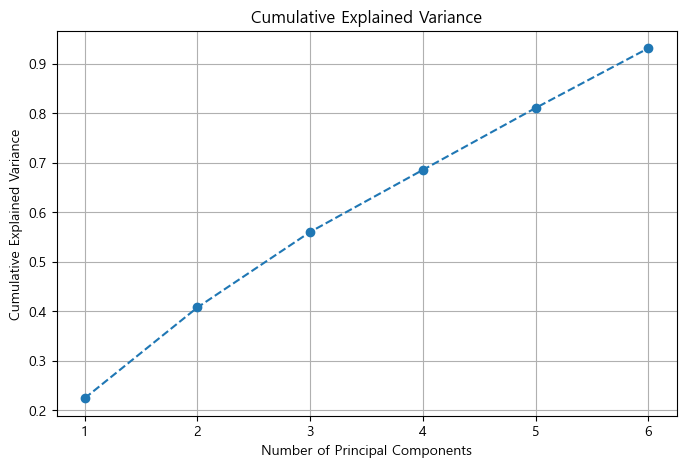

        PC1       PC2       PC3       PC4       PC5       PC6
0 -1.424745 -1.388545 -0.211815 -1.568959  0.475163  0.476862
1 -1.377116 -1.360215 -0.162269  0.937034 -1.047805 -0.125075
2  0.734594  1.582602 -1.340440 -0.508167  0.305280 -0.246913
3  0.639279  0.213816  0.093565  0.870547 -1.060157 -0.513054
4 -2.177300  0.992879  2.284181  0.362078  1.696753  0.004210


In [33]:
from sklearn.decomposition import PCA

# 1. PCA 객체 생성 및 적용
# 누적 설명 분산 비율을 기준으로 주요 성분 개수 결정
pca = PCA(n_components=0.9)  # 전체 분산의 90%를 유지하도록 설정
pca_data = pca.fit_transform(df_scaled)

# 2. 주요 정보 출력
print("주성분 개수:", pca.n_components_)  # 선택된 주성분 개수
print("설명된 분산 비율:", pca.explained_variance_ratio_)  # 각 성분의 분산 기여도
print("누적 설명 분산 비율:", pca.explained_variance_ratio_.cumsum())  # 누적 설명 비율

# 3. 설명 분산 비율 시각화
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

# 4. PCA 결과를 데이터프레임으로 변환
pca_columns = [f'PC{i+1}' for i in range(pca.n_components_)]  # 주성분 이름 지정
pca_df = pd.DataFrame(pca_data, columns=pca_columns)

# 결과 확인
print(pca_df.head())

### 🎯 PCA 누적 설명 분산 그래프 해석

#### ✅ 주요 결과

- **선택된 주성분 개수:** 6개
- **각 주성분의 설명된 분산 비율:**
  - PC1: 25.27%
  - PC2: 18.32%
  - PC3: 15.24%
  - PC4: 12.53%
  - PC5: 12.50%
  - PC6: 9.95%

- **누적 설명 분산 비율:**
  - PC1 ~ PC3: 약 58.8%
  - PC1 ~ PC6: 약 93.8%

---

#### 📊 그래프 해석

- **PC1~PC3만으로도 전체 분산의 절반 이상(58.8%)을 설명**할 수 있음
- **6개 주성분으로 전체 정보의 약 93%를 보존** → 효과적인 차원 축소
- 엘보우 지점이 뚜렷하진 않지만, 각 성분이 고르게 분산 기여  
  → 모든 주성분이 **의미 있는 정보**를 담고 있음

---

#### ✅ 결론

- **차원 축소 성능이 우수**하며, 정보 손실이 거의 없음
- 이후 클러스터링 및 모델링에 **PC1~PC6 사용 가능**
- **설명력, 계산 효율, 해석 가능성** 모두 고려했을 때 합리적인 구성


In [ ]:
# 주성분과 원본 변수 간의 관계 (주성분 구성 비율)
pca_components = pd.DataFrame(pca.components_, columns = df_scaled.columns, index= pca_columns)

print(pca_components.round(3))

### 🔍 PCA 주성분과 원본 변수 간의 관계 해석

다음 표는 각 주성분(PC1 ~ PC6)이 선택한 원본 변수들에 대해 어떻게 기여하는지를 나타냅니다.  
값의 절댓값이 클수록 해당 변수가 그 주성분에 강하게 기여하며, 부호는 기여의 방향(양/음)을 나타냅니다.

| 주성분 | log_duration | sales      | returned_amount | membership | device_desktop | device_mobile | device_other | high_spender |
|--------|--------------|------------|-----------------|------------|----------------|---------------|--------------|--------------|
| **PC1**  | 0.003       | **–0.692**  | 0.198           | –0.028    | 0.007         | –0.005       | –0.001      | **–0.694**   |
| **PC2**  | –0.005      | –0.005     | 0.002           | 0.008     | –0.763        | 0.575        | 0.295       | –0.007      |
| **PC3**  | –0.016      | 0.003      | 0.005           | 0.008     | –0.126        | –0.580       | 0.804       | –0.000      |
| **PC4**  | –0.199      | 0.020      | 0.262           | **0.944** | 0.008         | 0.002        | –0.013      | 0.016       |
| **PC5**  | **0.980**   | 0.010      | 0.067           | 0.188     | –0.005        | –0.007       | 0.011       | 0.007       |
| **PC6**  | –0.015      | 0.150      | **0.942**       | –0.270    | –0.003        | 0.001        | –0.003      | 0.130       |

---

#### 해석 요약

- **PC1**  
  - **주요 기여 변수**: `sales` (–0.692)와 `high_spender` (–0.694)  
  - **해석**: 이 주성분은 고객의 매출 및 고매출 여부와 밀접한 관련이 있습니다. 음의 부호는 값이 낮을수록 해당 특성이 강하게 나타남을 의미하므로, **PC1 값이 낮은 고객은 상대적으로 매출 및 고매출 특성이 강할 수 있음**.

- **PC2**  
  - **주요 기여 변수**: `device_desktop` (–0.763)와 `device_mobile` (+0.575)  
  - **해석**: 접속 기기 유형에 따른 차이를 반영합니다. 데스크탑 사용자는 음의 방향, 모바일 사용자는 양의 방향으로 기여하여, **PC2는 디바이스 선호도(데스크탑 vs. 모바일)를 구분**하는 축입니다.

- **PC3**  
  - **주요 기여 변수**: `device_mobile` (–0.580)와 `device_other` (+0.804)  
  - **해석**: 이 주성분은 모바일과 기타 디바이스 사용 간의 대조를 보여줍니다. 모바일 사용자는 음의 기여, 기타 기기는 양의 기여로 작용하여 **세분화된 디바이스 선호 패턴**을 나타냅니다.

- **PC4**  
  - **주요 기여 변수**: `membership` (**+0.944**)  
  - **해석**: 회원 등급이 거의 전적으로 이 주성분을 결정합니다. 따라서 **PC4는 고객의 멤버십 등급을 대표하는 축**으로, 등급이 높을수록 PC4 값이 높게 나타날 수 있습니다.

- **PC5**  
  - **주요 기여 변수**: `log_duration` (**+0.980**)  
  - **해석**: 체류 시간이 주요 요인으로 작용합니다. PC5는 **고객의 체류 시간**을 반영하며, 체류 시간이 길수록 이 주성분의 값이 높게 나타납니다.

- **PC6**  
  - **주요 기여 변수**: `returned_amount` (**+0.942**)  
  - **해석**: 반품 금액이 주로 기여합니다. 이 주성분은 **반품 행동**과 관련이 있으며, 반품 금액이 큰 고객이 PC6에서 높은 값을 보입니다.

---

#### 결론

- **PC1, PC4, PC5, PC6**은 각각 **매출/고매출, 회원 등급, 체류 시간, 반품 금액**과 관련되어 있어, 고객의 재무적 및 행동적 특성을 잘 반영합니다.
- **PC2와 PC3**은 **접속 기기** 관련 변수에 의해 주로 결정되어, 고객의 디지털 채널 선호도를 나타내는 중요한 축입니다.
- 이와 같이 각 주성분이 특정 비즈니스 및 행동적 특성을 명확하게 구분해 주기 때문에, **해석 용이성과 후속 고객 세분화 작업에 매우 유용한 결과**로 볼 수 있습니다.


## 클러스터링
1. K-Means
  - 클러스터 중심(centroid)을 기반으로 데이터 포인트 군집화
  - 여기서는 **Mini-Batch K-Means** 사용
      - 대규모 데이터에 적합한 빠른 클러스터링 알고리즘(K-Means의 변형)
      - baseline 역할
2. **HDBSCAN**
 - HDBSCAN은 클러스터 수를 자동으로 결정하며, 이상치 탐지 기능이 내장된 밀도 기반 클러스터링 알고리즘
 - DBSCAN보다 파라미터에 덜 민감하고, 고차원 데이터에서도 안정적으로 군집 구조를 도출
 - 실루엣 점수는 다소 낮을 수 있지만, 실무에서는 해석 용이성과 자동화 측면에서 유용하게 활용

3. **Agglomerative Clustering(Hierarchical Clustering)**
  - 계층적 방법으로, 클러스터를 bottom-up 방식으로 생성
  - 클러스터의 계층적 구조를 이해하고자 할 때 유용
  - 여기서는 전체 데이터에 한번에 적용하기 계산 부담이 따르므로 배치 단위로 fit_predict를 반복
4. **Gaussian Mixture Model(GMM)**
  - 클러스터를 정규분포로 가정하여 데이터 포인트의 소속 확률 계산
  - 클러스터 간 경계가 명확하지 않은 경우 적합

> **보완: RAM 용량 문제로 다음과 같이 수정함**
    > - 주성분을 6개 유지
    > - 기본 K-Means 대신 Mini-Batch K-Means 사용
    > - `batch_size=100`하여 한 번에 처리하는 데이터 크기를 제한해 계산 부담 감소
    > - DBSCAN 파라미터 최적화: eps를 1.5에서 2.0으로 늘리고, min_samples를 10에서 15로 조정하여 계산량을 줄임
    > - `covariance_type='diag'`(대각 공분산 행렬)을 사용하여 계산 효율성을 높임
    > - PC1과 PC2만 시각화하여 결과를 직관적으로 확인

| 알고리즘                  | 클러스터 수 지정 | 이상치 탐지 | 특징 요약                                                                 | 장점                                                 | 단점                                                     |
|---------------------------|------------------|--------------|---------------------------------------------------------------------------|--------------------------------------------------------|------------------------------------------------------------|
| K-Means                   | O (필수)         | X            | 가장 대표적인 중심 기반 클러스터링, 거리 기반으로 군집화                | 간단하고 직관적, 빠름                                 | 군집 수 지정 필요, 이상치에 민감, 비선형 구조 탐지 어려움 |
| **Mini-Batch K-Means**        | O (필수)         | X            | KMeans의 경량 버전, 소규모 배치로 클러스터링 수행                        | 속도 빠름, 대용량 데이터에 적합                        | 정확도는 KMeans보다 약간 낮을 수 있음                    |
| **Gaussian Mixture Model**    | O (필수)         | X            | 각 클러스터를 정규분포로 모델링, 확률 기반 군집                         | 유연한 클러스터 표현 가능                              | 계산 복잡, 클러스터 수 지정 필요                          |
| **Agglomerative Clustering**  | O (필수)         | X            | 계층적 군집화, 트리 구조(덴드로그램)를 활용해 군집 생성                 | 계층 구조 시각화 가능                                 | 대용량 데이터에 부적합, 느릴 수 있음                      |
| DBSCAN                    | X                | O            | 밀도 기반 군집화, 밀집된 영역은 군집으로, 나머지는 노이즈로 분류       | 이상치 탐지 가능, 군집 수 자동 결정                   | 파라미터 설정에 민감, 클러스터 밀도 차이 클 경우 성능 저하 |
| **HDBSCAN**                   | X (자동 결정)    | O            | DBSCAN 확장판, 클러스터 안정성 기반으로 유연하게 군집화                | 이상치 감지 + 클러스터 수 자동 결정                   | 파라미터 설정 복잡, 해석 어려울 수 있음                   |


- ***일단 여러 방법을 빠르게 시도해보고, 메모리 문제를 피해보기 위해***  다양한 클러스터링 알고리즘 시도  
   - 각 클러스터링 알고리즘에 따른 최적의 클러스터 수는 elbow method, 실루엣 스코어에 의해 달라질 수 있다.
   
> **최종 선택 클러스터링 알고리즘**  
    - 군집의 해석 가능성, 클러스터 수 자동화, 이상치 감지 능력, 실무 활용도 등도 함께 고려해야

    - ✅ 클러스터링 알고리즘 선택 이유
         - 여러 알고리즘 중 **DBSCAN이 가장 높은 실루엣 점수 (0.2992)** 를 기록했지만,  
         - **HDBSCAN은 클러스터 수 자동 결정 + 이상치 감지 기능**으로 인해 실무적 해석이 용이함.
         - 특히 고객 분류 및 노이즈 탐지 목적에서 HDBSCAN의 해석 가능성과 응용성이 더 높다고 판단.
         - 최종적으로 HDBSCAN을 주요 분석 알고리즘으로 선정.


In [34]:
# DBSCAN 대신 HDBSCAN
from sklearn.cluster import MiniBatchKMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
import hdbscan

# 1. PCA 주성분 6개 유지 및 float32 변환
pca_data_6 = pca_data[:, :6].astype(np.float32)

# 2. 클러스터링 결과 저장용 딕셔너리
results = {}

# 1) Mini-Batch K-Means
try:
    mb_kmeans = MiniBatchKMeans(n_clusters=5, random_state=42, batch_size=1024)
    mb_kmeans_labels = mb_kmeans.fit_predict(pca_data_6)
    results['Mini-Batch K-Means'] = mb_kmeans_labels
except Exception as e:
    print(f"Mini-Batch K-Means failed: {e}")

# 2) HDBSCAN - min_cluster_size=300, min_samples=30 + cluster_selection_epsilon=0.2 추가
try:
    hdb = hdbscan.HDBSCAN(min_cluster_size=300, min_samples=30, cluster_selection_epsilon=0.2)
    hdb_labels = hdb.fit_predict(pca_data_6)
    results['HDBSCAN'] = hdb_labels
except Exception as e:
    print(f"HDBSCAN failed: {e}")

# 3) Gaussian Mixture Model
try:
    gmm = GaussianMixture(n_components=5, covariance_type='diag', random_state=42)
    gmm_labels = gmm.fit_predict(pca_data_6)
    results['Gaussian Mixture Model'] = gmm_labels
except Exception as e:
    print(f"Gaussian Mixture Model failed: {e}")

# 4) Agglomerative Clustering (배치 처리)
try:
    batch_size = 5000
    agglo_labels = []
    for i in range(0, len(pca_data_6), batch_size):
        batch = pca_data_6[i:i+batch_size]
        agglo = AgglomerativeClustering(n_clusters=5, linkage='ward')
        batch_labels = agglo.fit_predict(batch)
        agglo_labels.extend(batch_labels)
    results['Agglomerative Clustering'] = np.array(agglo_labels)
except Exception as e:
    print(f"Agglomerative Clustering failed: {e}")

Plotting Mini-Batch K-Means results...


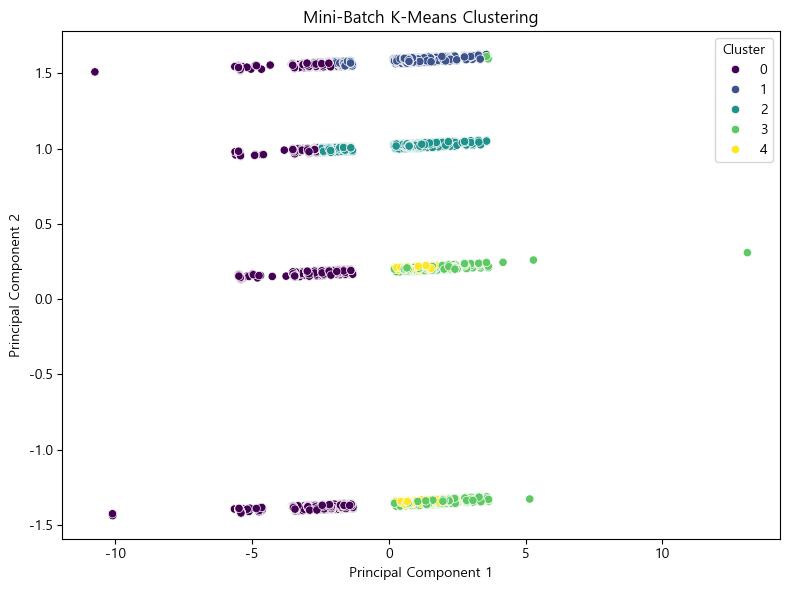

Plotting HDBSCAN results...


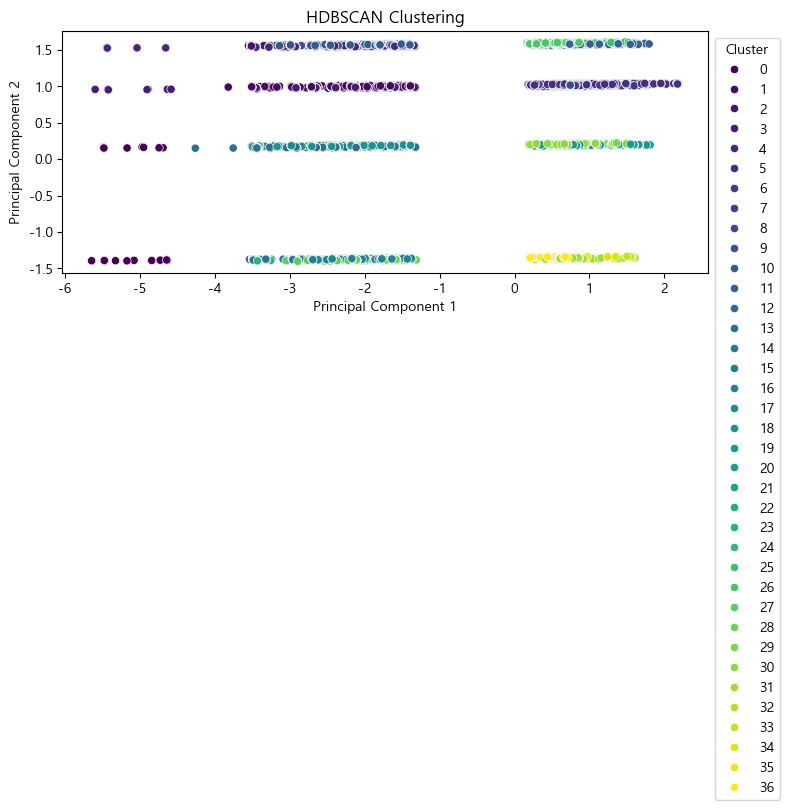

Plotting Gaussian Mixture Model results...


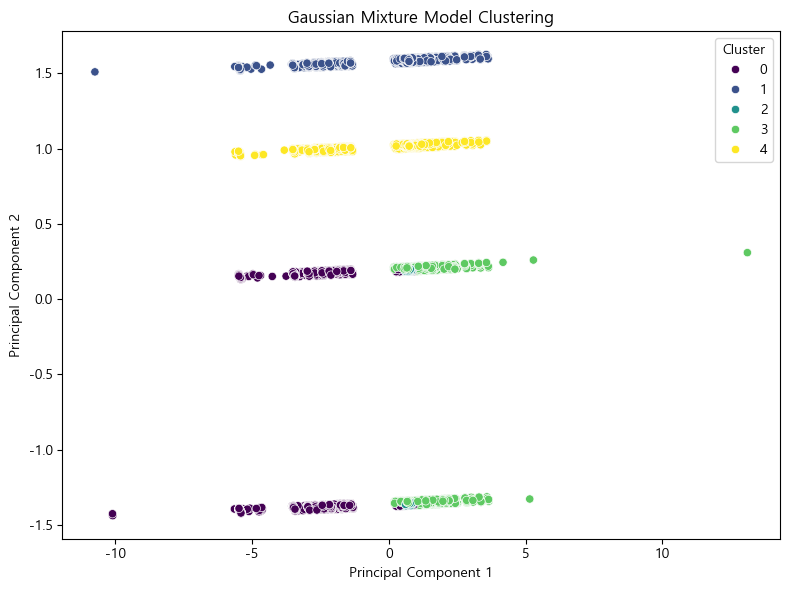

Plotting Agglomerative Clustering results...


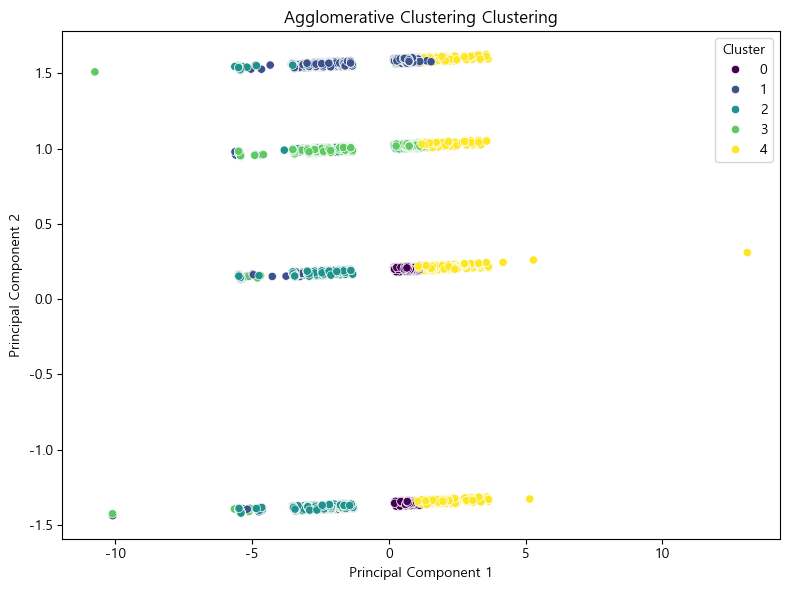

In [34]:
# 3. 클러스터링 결과 시각화 (PC1 vs PC2)
def plot_clusters(data, labels, title):
    plt.figure(figsize=(8, 6))
    # 이상치 (-1) 필터링
    mask = labels != -1
    sns.scatterplot(x=data[mask, 0], y=data[mask, 1], hue=labels[mask], palette='viridis', legend='full')
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(title='Cluster', loc='best', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

# 각 모델의 결과 시각화
for model_name, labels in results.items():
    print(f"Plotting {model_name} results...")
    plot_clusters(pca_data_6, labels, f"{model_name} Clustering")

### 클러스터링 결과 요약 분석(PC1 vs. PC2 시각화 기반)



### 실루엣 점수 개선 시도
🔽 Mini-Batch KMeans, GMM으로 최적의 클러스터 수 찾기  
🔽 DBSCAN 최적 eps 찾기

- Agglomerative 는 메모리 이슈, 낮은 실루엣 점수로 제외
- 실무에서도 대용량 데이터에서 잘 채택되지 않는 알고리즘

In [36]:
summary_tables = {}

for model_name, labels in results.items():
    df_with_labels = df_scaled.copy()
    df_with_labels['cluster'] = labels
    if len(set(labels)) > 1:  # 클러스터가 1개 이상일 때만 집계
        summary = df_with_labels.groupby('cluster')[selected_columns].mean().round(2)
        summary['size'] = df_with_labels['cluster'].value_counts().sort_index()
        summary_tables[model_name] = summary

# 결과 확인
for model, table in summary_tables.items():
    print(f"\n📌 {model} 클러스터별 요약\n")
    display(table)


📌 Mini-Batch K-Means 클러스터별 요약



,duration_(secs),sales,returned_amount,membership,device_desktop,device_mobile,device_other,high_spender,size
cluster,,,,,,,,,
0,-0.00,1.48,-0.20,0.03,0.26,-0.20,-0.31,1.67,34719
1,-0.00,-0.31,0.02,-0.00,-0.82,1.88,-0.43,-0.23,33478
2,-0.01,-0.18,0.01,0.00,-0.82,-0.53,2.35,-0.10,25175
3,0.85,-0.46,0.21,0.02,0.50,-0.53,-0.43,-0.60,39864
4,-0.85,-0.46,-0.06,-0.05,0.49,-0.53,-0.43,-0.60,39602



📌 HDBSCAN 클러스터별 요약



,duration_(secs),sales,returned_amount,membership,device_desktop,device_mobile,device_other,high_spender,size
cluster,,,,,,,,,
-1,0.01,0.96,3.94,0.05,0.24,-0.03,-0.18,0.08,3752
0,-0.02,6.14,-0.20,0.75,0.48,-0.53,-0.43,1.67,639
1,0.01,1.12,-0.20,0.75,-0.82,-0.53,2.35,1.67,4600
2,0.01,3.30,-0.20,0.75,-0.82,1.88,-0.43,1.67,428
3,0.01,1.30,-0.20,-1.49,-0.82,-0.53,2.35,1.67,2220
4,-0.02,1.26,-0.20,-1.49,-0.82,1.88,-0.43,1.67,3242
5,-0.01,-0.45,0.04,0.75,-0.82,-0.53,2.35,-0.60,11723
6,-0.02,-0.44,0.01,-1.49,-0.82,-0.53,2.35,-0.60,5246
7,-1.44,-0.52,-0.20,-0.37,-0.82,-0.53,2.35,-0.60,428



📌 Gaussian Mixture Model 클러스터별 요약



,duration_(secs),sales,returned_amount,membership,device_desktop,device_mobile,device_other,high_spender,size
cluster,,,,,,,,,
0,-0.00,1.23,-0.20,-0.01,0.49,-0.53,-0.43,1.62,29235
1,-0.00,0.00,-0.00,0.00,-0.82,1.88,-0.43,0.00,38226
2,0.00,-0.47,-0.19,-1.11,0.50,-0.53,-0.43,-0.60,29396
3,0.01,-0.45,0.23,0.66,0.49,-0.53,-0.43,-0.60,49389
4,-0.01,0.00,-0.00,0.01,-0.82,-0.53,2.35,-0.00,26592



📌 Agglomerative Clustering 클러스터별 요약



,duration_(secs),sales,returned_amount,membership,device_desktop,device_mobile,device_other,high_spender,size
cluster,,,,,,,,,
0,0.00,-0.45,-0.15,-0.01,0.48,-0.50,-0.42,-0.59,73945
1,-0.00,0.80,-0.19,0.02,-0.14,0.50,-0.30,1.05,38517
2,-0.00,0.17,-0.16,0.00,-0.62,-0.27,1.63,0.24,26934
3,-0.00,0.04,-0.13,0.00,-0.49,0.90,-0.01,0.05,26265
4,0.01,-0.52,3.58,0.01,-0.03,0.18,-0.12,-0.60,7177


### 클러스터링 결과 평가 및 주요 인사이트

#### ✅ 평가 지표 요약

| 알고리즘                  | 실루엣 점수 | 클러스터 수 | 노이즈 비율 | 주요 특징 |
|---------------------------|-------------|--------------|--------------|-------------------------------|
| Mini-Batch K-Means        | 0.2646      | 5            | 없음         | 고매출/저매출 군집 구분 명확 |
| HDBSCAN                   | 0.2372      | 36 (+ 노이즈) | 2.17%       | 미세한 세분화 및 반품 클러스터 포착 |
| Gaussian Mixture Model    | 0.2660      | 5            | 없음         | 고매출 고객 군집 명확하나 해석성은 다소 약함 |
| Agglomerative Clustering  | 0.1750      | 5            | 없음         | 고반품 클러스터 분리 가능, 분포 불균형 존재 |


### 클러스터링 평가
1. 정량적 지표
    - Silhouette Score
    - Davies-Bouldin Index
    - Calinski-Harabasz Score (보조 지표)
2. 정성적 지표
    - PC1 vs PC2 산점도
    - 클러스터 응집도
    - 이상치 분포

**📌 클러스터링 평가 지표 요약**

- **Silhouette Score**: 응집도 + 분리도 기준으로 가장 널리 사용되는 정량 지표
- **Noise Ratio (HDBSCAN 등)**: 이상치 비율 확인 (비즈니스적으로 제거 or 타겟팅 판단)
- **클러스터별 통계 요약**: 각 클러스터의 주요 특성을 평균 등으로 비교해 인사이트 도출
- **2D/3D 시각화 (t-SNE, UMAP)**: 정성적으로 잘 나뉘는지 시각화로 확인
- **비즈니스 적용성**: 클러스터가 실제 마케팅 타겟/고객군으로 해석 가능한지 여부

In [35]:
# HDBSCAN 실루엣 점수 포함
from sklearn.metrics import silhouette_score

# 실루엣 점수 계산 함수
def calculate_silhouette(data, labels, model_name):
    """
    클러스터링 레이블로 실루엣 점수를 계산하는 함수.
    클러스터가 1개 이하인 경우 점수 계산 불가.
    """
    try:
        if len(set(labels)) > 1 and -1 in labels:  # -1(이상치) 포함 시
            mask = labels != -1  # 이상치 제외
            score = silhouette_score(data[mask], labels[mask])
            print(f"{model_name} Silhouette Score: {score:.4f}")
            return score
        elif len(set(labels)) > 1:  # 이상치가 없고, 클러스터가 2개 이상인 경우
            score = silhouette_score(data, labels)
            print(f"{model_name} Silhouette Score: {score:.4f}")
            return score
        else:
            print(f"{model_name} has only one cluster, Silhouette Score not applicable.")
            return None
    except Exception as e:
        print(f"{model_name} Silhouette Score calculation failed: {e}")
        return None

# 모델별 실루엣 점수 저장
scores = {}

# 모델별 결과가 있는 경우만 평가
try:
    if 'Mini-Batch K-Means' in results:
        scores['Mini-Batch K-Means'] = calculate_silhouette(pca_data_6, results['Mini-Batch K-Means'], "Mini-Batch K-Means")
    if 'HDBSCAN' in results:
        scores['HDBSCAN'] = calculate_silhouette(pca_data_6, results['HDBSCAN'], "HDBSCAN")
    if 'Agglomerative Clustering' in results:
        scores['Agglomerative Clustering'] = calculate_silhouette(pca_data_6, results['Agglomerative Clustering'], "Agglomerative Clustering")
    if 'Gaussian Mixture Model' in results:
        scores['Gaussian Mixture Model'] = calculate_silhouette(pca_data_6, results['Gaussian Mixture Model'], "Gaussian Mixture Model")
except Exception as e:
    print(f"Silhouette Score calculation failed: {e}")

# 출력
print("\n📊 최종 Silhouette Scores:")
for model_name, score in scores.items():
    print(f"{model_name} Silhouette Score: {score:.4f}" if score is not None else f"{model_name}: Not Applicable")

Mini-Batch K-Means Silhouette Score: 0.2646
HDBSCAN Silhouette Score: 0.2372
Agglomerative Clustering Silhouette Score: 0.1750
Gaussian Mixture Model Silhouette Score: 0.2660

📊 최종 Silhouette Scores:
Mini-Batch K-Means Silhouette Score: 0.2646
HDBSCAN Silhouette Score: 0.2372
Agglomerative Clustering Silhouette Score: 0.1750
Gaussian Mixture Model Silhouette Score: 0.2660


#### Silhouette Score 기준 - 클러스터링 성능 비교

- Silhouette Score는 각 데이터가 **자신의 클러스터 내부에서 얼마나 응집되어 있고**, **다른 클러스터와 얼마나 잘 분리되어 있는지**를 나타내는 지표
- **값이 1에 가까울수록 좋으며**, **0.25~0.5는 보통**, **0.5 이상은 양호한 군집화 품질**로 간주된다.

| 알고리즘 | Silhouette Score | 해석 |
|----------|------------------|------|
| **Mini-Batch K-Means** | 0.2646 | 보통 수준의 클러스터링 성능. 빠르고 해석 가능한 군집 구조를 제시 |
| **HDBSCAN** | 0.2372 | 다소 낮은 편이지만, 밀도 기반 특성상 복잡한 데이터 구조를 잘 반영할 수 있음 |
| **Agglomerative Clustering** | 0.1750 | 가장 낮은 수치. 군집 간 중첩 또는 비효율적인 병합 가능성 존재 |
| **Gaussian Mixture Model** | 0.2660 | 가장 높은 점수. 혼합 모델 기반으로 유연하고 응집력 있는 군집 형성 가능 |

> **결론 요약**  
> - **Gaussian Mixture Model**과 **Mini-Batch K-Means**가 상대적으로 더 우수한 군집 품질을 보임.  
> - **HDBSCAN**은 실루엣 점수가 낮지만, **복잡한 분포를 탐색하는 데 유리**한 알고리즘.
> - **Agglomerative Clustering**은 이번 데이터셋에서는 적합도가 가장 낮게 나타났음.

In [32]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd
import numpy as np

# 1. Davies-Bouldin Index 출력 
print("==== Davies-Bouldin Index (각 알고리즘별) ====\n")
for model_name, labels in results.items():
    print(f"--- {model_name} ---")
    # DBI는 이상치(-1)가 없고 클러스터가 2개 이상일 때 계산
    if len(set(labels)) > 1 and -1 not in labels:
        dbi = davies_bouldin_score(pca_data_6, labels)
        print(f"Davies-Bouldin Index: {dbi:.4f}")
    else:
        print("Davies-Bouldin Index: Not Applicable")
    print()

# 2. 클러스터 크기 출력 
print("==== 클러스터 크기 (각 알고리즘별) ====\n")
for model_name, labels in results.items():
    print(f"--- {model_name} ---")
    sizes = pd.Series(labels).value_counts().sort_index()
    print(sizes)
    print()

# 3. 노이즈 비율 (HDBSCAN만 해당)
if 'HDBSCAN' in results:
    hdb_labels = results['HDBSCAN']
    noise_ratio = (hdb_labels == -1).sum() / len(hdb_labels)
    print(f"HDBSCAN Noise Ratio: {noise_ratio:.2%}")

==== Davies-Bouldin Index (각 알고리즘별) ====

--- Mini-Batch K-Means ---
Davies-Bouldin Index: 1.3714

--- HDBSCAN ---
Davies-Bouldin Index: Not Applicable

--- Gaussian Mixture Model ---
Davies-Bouldin Index: 1.3253

--- Agglomerative Clustering ---
Davies-Bouldin Index: 2.6518

==== 클러스터 크기 (각 알고리즘별) ====

--- Mini-Batch K-Means ---
0    34719
1    33478
2    25175
3    39864
4    39602
Name: count, dtype: int64

--- HDBSCAN ---
-1      3752
 0       639
 1      4600
 2       428
 3      2220
 4      3242
 5     11723
 6      5246
 7       428
 8      2044
 9       466
 10     5681
 11     7607
 12     3448
 13     3169
 14      778
 15      875
 16    10407
 17      607
 18     5975
 19     7577
 20     1034
 21      380
 22     2069
 23      352
 24     6483
 25      500
 26    16066
 27     1957
 28     3170
 29      493
 30    16015
 31    13489
 32      408
 33      389
 34      514
 35      361
 36    28246
Name: count, dtype: int64

--- Gaussian Mixture Model ---
0    29235
1    3

#### 그 외 클러스터링 성능 평가 및 해석

##### 1. Davies-Bouldin Index (DBI)

Davies-Bouldin Index는 클러스터 간 분리도와 응집도를 함께 고려하여 군집의 품질을 평가하는 지표입니다. **값이 낮을수록 좋은 클러스터링**을 의미합니다.

| 알고리즘 | DBI 점수 | 해석 |
|----------|-----------|------|
| Mini-Batch K-Means | 1.3714 | 양호한 편으로, 군집 간 경계가 비교적 잘 형성되어 있음 |
| HDBSCAN | Not Applicable | 밀도 기반 군집에서 DBI는 해석이 부적절할 수 있어 생략됨 |
| Gaussian Mixture Model | 1.3253 | K-Means보다 약간 낮은 수치로, 혼합 모델이 잘 작동한 사례 |
| Agglomerative Clustering | 2.6518 | 비교적 높은 수치로, 군집 간 중첩 또는 응집도 부족 가능성 있음 |

---

##### 2. 클러스터 크기 분포 (군집 균형도)

클러스터가 **균형적으로 분포되어 있을수록** 해석 및 활용 측면에서 유리합니다.

- **Mini-Batch K-Means**
  - 5개 클러스터가 비교적 균형 있게 분포 (25k~39k 사이)
  - 마케팅 타겟팅이나 리텐션 전략 수립에 유리한 군집 분포

- **HDBSCAN**
  - 총 37개 클러스터 + 1개 노이즈 그룹 (-1)
  - 가장 큰 클러스터는 28,246건, 가장 작은 클러스터는 352건
  - 다양한 크기의 클러스터로 세분화된 고객군을 탐색할 수 있지만, 과도한 분할 위험도 존재

- **Gaussian Mixture Model**
  - 5개 클러스터로 구성, 크기는 26k~49k 사이로 균형적
  - 클러스터 간 혼합 구조를 가정하여 유연한 분류가 가능

- **Agglomerative Clustering**
  - 5개 클러스터 중 하나가 전체의 절반 이상을 차지 (73,945건)
  - 다른 클러스터와 비교해 분포가 불균형하여 군집 해석에 주의 필요

---

##### 3. HDBSCAN의 노이즈 비율

- **노이즈 비율: 2.17% (3,752건)**
  - 밀도 기반 클러스터링 알고리즘에서 노이즈는 의미 있는 이상치 또는 군집되지 않은 데이터를 의미
  - 2% 수준은 적절한 수치로, 데이터의 전체적인 품질이나 응집도가 양호하다고 해석할 수 있음

---

##### ✅ 종합 평가 요약

| 알고리즘 | 분리도 (DBI) | 군집 수 | 분포 균형 | 해석 가능성 |
|----------|-------------|----------|------------|-------------|
| **Mini-Batch K-Means** | 보통 (~1.37) | 5 | 좋음 | 실용적, 이해 쉬움 |
| **HDBSCAN** | N/A | 37 + noise | 불균형 (작은 군집 다수) | 세분화에 유리, 복잡한 해석 필요 |
| **Gaussian Mixture** | 좋음 (~1.32) | 5 | 양호 | 유연한 군집 가능 |
| **Agglomerative** | 낮음 (~2.65) | 5 | 매우 불균형 | 해석 및 활용 어려움 |

> **결론**:  
> - **Mini-Batch K-Means**와 **Gaussian Mixture Model**은 균형성과 성능 측면에서 포트폴리오용 분석에 안정적인 선택으로 평가됩니다.  
> - **HDBSCAN**은 세밀한 군집 구분이 필요한 경우 유용하지만, 복잡성과 해석 난이도를 고려해 보완 설명이 필요합니다.


### 후속 해석: 추가 시각화

- **t-SNE (t-distributed Stochastic Neighbor Embedding)**
    - 고차원 데이터를 저차원(보통 2D)으로 시각화할 때 국소 구조(가까운 점들 간의 관계)를 잘 보존하는 비선형 차원 축소 기법
- **UMAP (Uniform Manifold Approximation and Projection)**
    - t-SNE보다 계산 효율이 좋고, 전체적인 데이터 구조(글로벌/로컬)를 함께 잘 보존하는 차원 축소 알고리즘
- 두 알고리즘 모두 **클러스터링 결과의 분포, 경계, 이상치 등을 시각적으로 이해**하기 위해 사용된다.
- 특히 분리된 클러스터가 시각적으로 잘 구분되는지 확인하고, 노이즈나 겹침 여부를 판단하는 데 유용.


Plotting Mini-Batch K-Means t-SNE visualization...


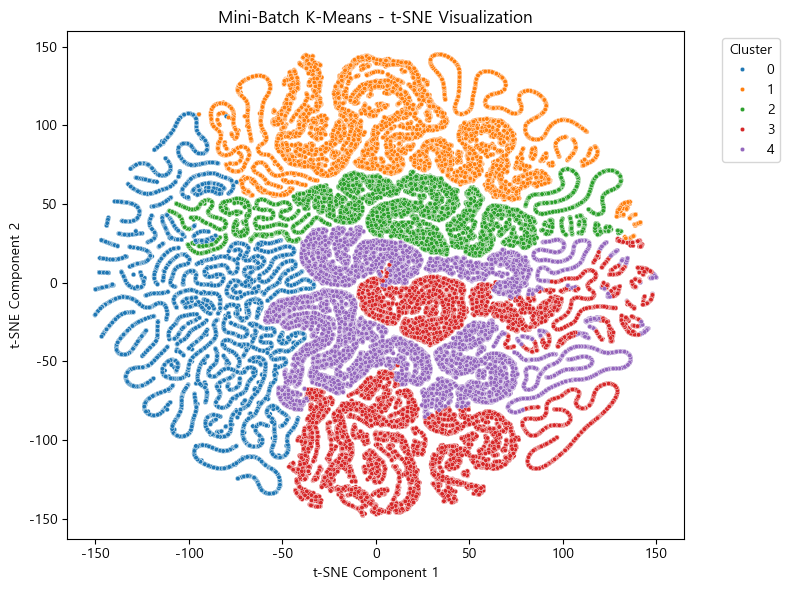

Plotting HDBSCAN t-SNE visualization...


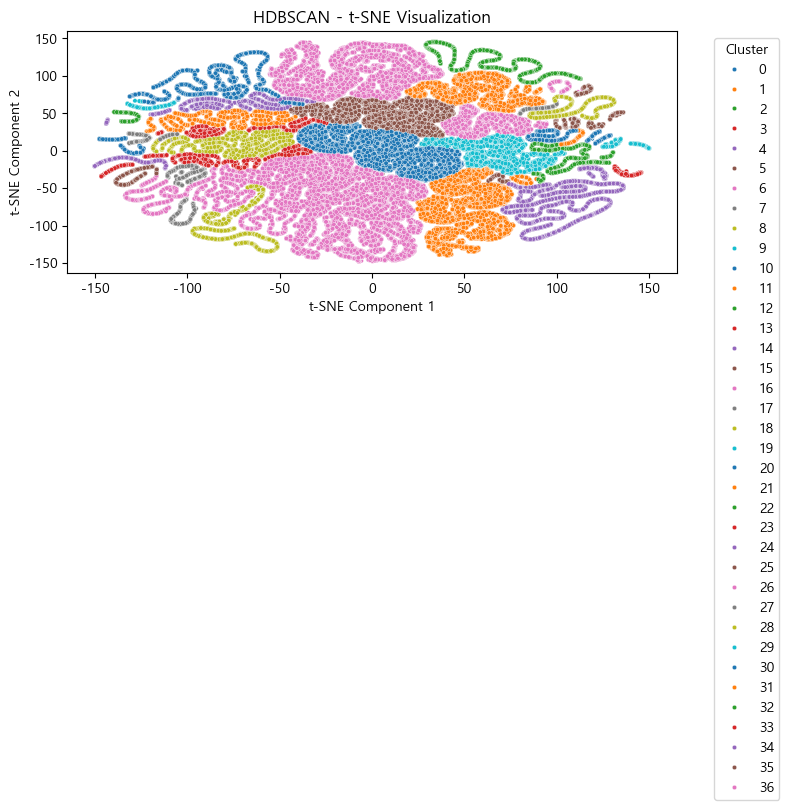

Plotting Gaussian Mixture Model t-SNE visualization...


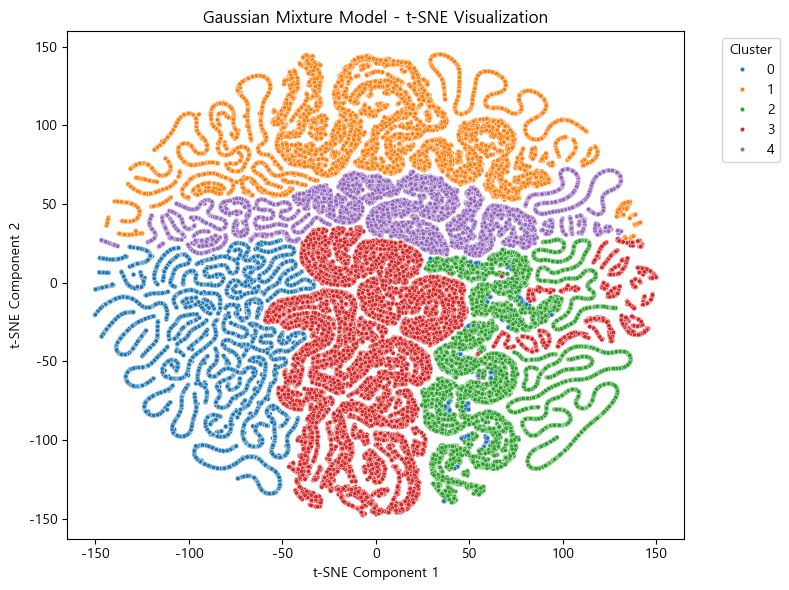

Plotting Agglomerative Clustering t-SNE visualization...


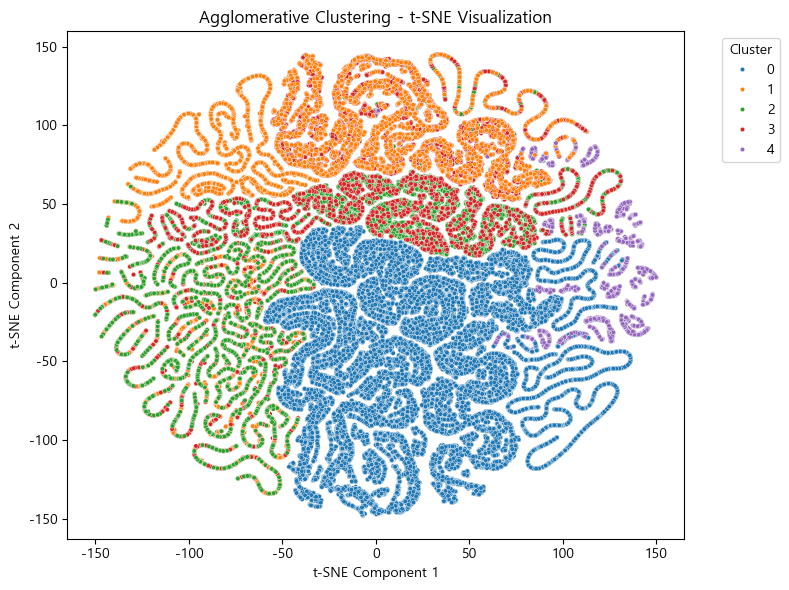

In [33]:
# 1. t-SNE 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

def plot_tsne(data, labels, model_name):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    tsne_result = tsne.fit_transform(data)
    
    # 이상치(-1) 마스킹 (HDBSCAN에서 noise 처리 시)
    mask = labels != -1
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=tsne_result[mask, 0], y=tsne_result[mask, 1], 
                    hue=labels[mask], palette='tab10', s=10, legend='full')
    plt.title(f"{model_name} - t-SNE Visualization")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# 각 알고리즘 별로 t-SNE 시각화 실행
for model_name, labels in results.items():
    print(f"Plotting {model_name} t-SNE visualization...")
    plot_tsne(pca_data_6, labels, model_name)

#### 📊 t-SNE 시각화 결과 해석 (클러스터링 알고리즘별 비교)

##### 1. Mini-Batch K-Means
- **분포 해석**: 클러스터 간 경계가 명확하며, 균일하게 분포되어 있음.
- **의미**: 중심 기반 알고리즘으로, 원형 군집을 잘 찾아냄.
- **해석 용이성**: 각 군집이 뚜렷하게 구분되어 마케팅 타깃 세분화 등에 적합.

---

##### 2. HDBSCAN
- **분포 해석**: 다양한 크기·형태의 클러스터가 존재하고, 일부는 복잡하게 얽혀 있음.
- **의미**: 밀도 기반 클러스터링의 특성이 잘 드러나며, 중심이 없는 불규칙한 클러스터를 탐지함.
- **주의사항**: 노이즈(-1 레이블)가 적절히 분리되었으나, 클러스터 수가 많아 해석이 어려울 수 있음.
- **활용도**: 고객 행동이 복잡하거나 비선형적인 구조일 때 유용. 단, 클러스터 수 정제 필요.

---

##### 3. Gaussian Mixture Model (GMM)
- **분포 해석**: K-Means와 유사하지만 클러스터 간 경계가 더 부드러움.
- **의미**: 확률 기반 클러스터링이므로 데이터 포인트가 여러 클러스터에 소속될 수 있는 구조를 잘 표현함.
- **활용도**: 군집 간의 경계가 모호한 고객 데이터를 분석할 때 효과적.

---

##### 4. Agglomerative Clustering
- **분포 해석**: 일부 클러스터가 넓게 확산되며, 경계가 흐릿하게 나타남.
- **의미**: 계층적 클러스터링의 특성상 일부 세분화가 덜 정제되어 있음.
- **활용도**: 계층 구조 기반의 고객 세분화를 원할 때 유용. 다만, 대규모 데이터에선 성능 한계 존재.

---

##### ✅ 알고리즘별 비교 요약

| 알고리즘                  | 클러스터 경계 | 클러스터 수 | 해석 용이성 | 비고                                       |
|---------------------------|----------------|--------------|--------------|--------------------------------------------|
| **Mini-Batch K-Means**    | 명확            | 적절(5개)     | 높음          | 균일한 패턴 분석에 유리                    |
| **HDBSCAN**               | 복잡·자유        | 많음(37개)    | 낮음          | 밀도 기반 탐지 우수, 클러스터 정제 필요     |
| **Gaussian Mixture Model**| 부드러움         | 적절(5개)     | 중간          | 확률적 클러스터링, 혼합 패턴에 강함         |
| **Agglomerative**         | 흐릿함          | 적절(5개)     | 중간          | 계층 분석에 적합, 대규모에선 주의           |

---

##### 💡 실무 적용 제안
- **명확한 클러스터 분리 및 해석이 필요할 때**: `Mini-Batch K-Means`, `GMM` 추천
- **복잡한 고객 행동 구조 탐지 시**: `HDBSCAN` 유리 (단, 클러스터 수 조정 권장)
- **고객군을 트리 형태로 나누고 싶을 때**: `Agglomerative Clustering` 고려

Plotting Mini-Batch K-Means UMAP visualization...


C:\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


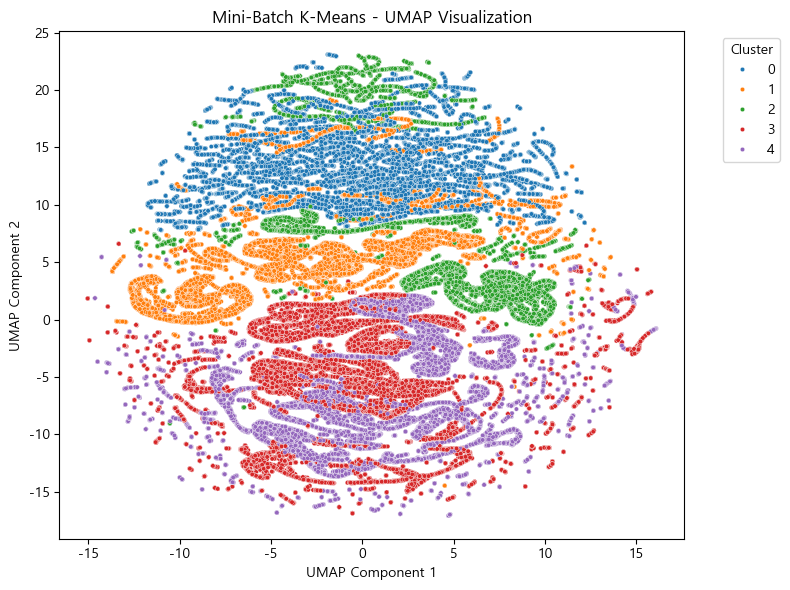

Plotting HDBSCAN UMAP visualization...


C:\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


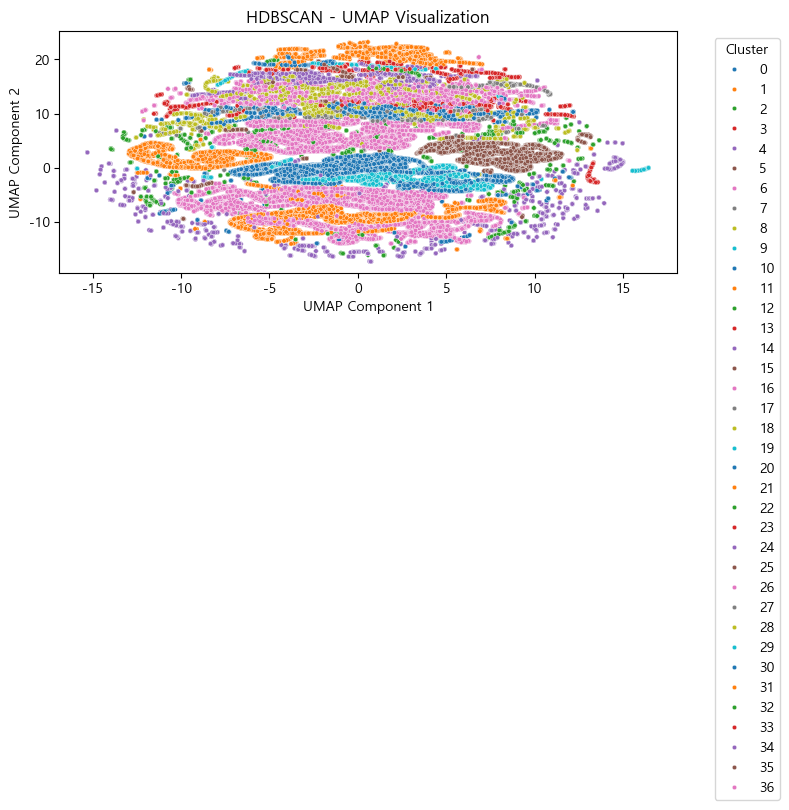

Plotting Gaussian Mixture Model UMAP visualization...


C:\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


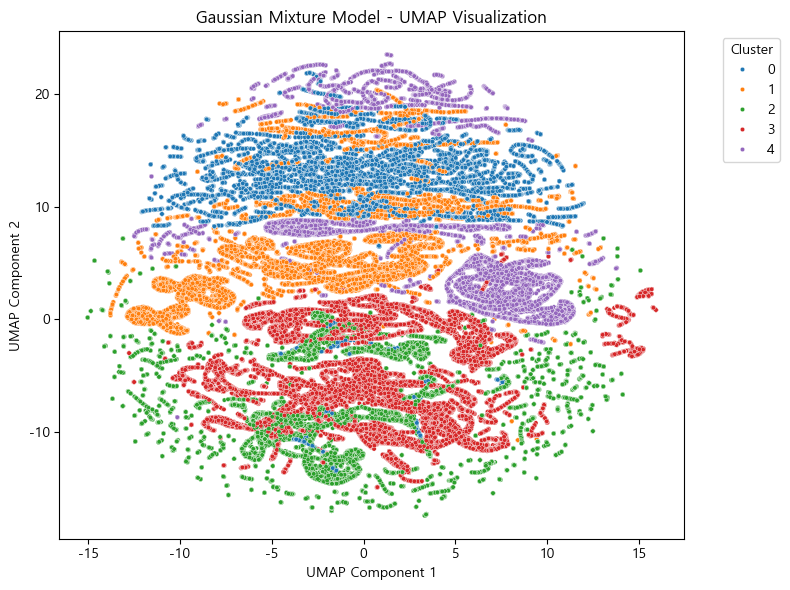

Plotting Agglomerative Clustering UMAP visualization...


C:\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


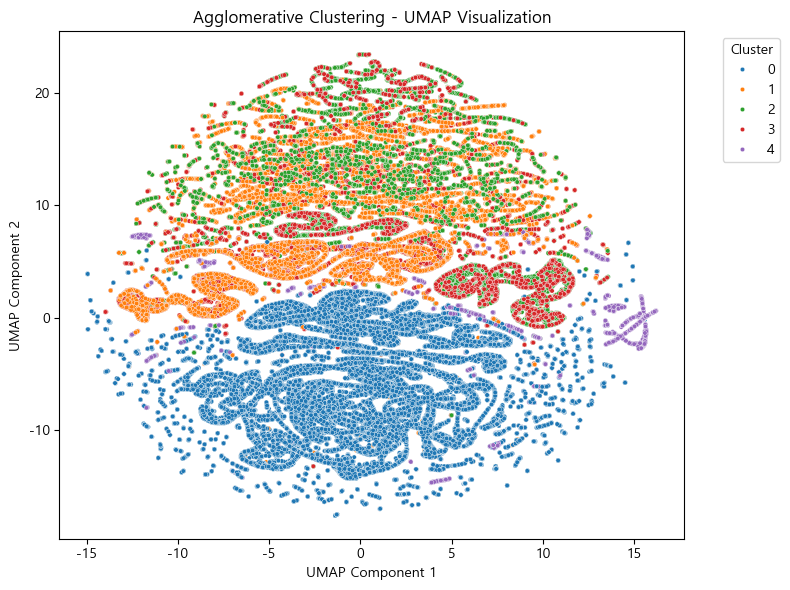

In [34]:
# ✅ UMAP 
# !pip install umap-learn #umap-learn 설치
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

def plot_umap(data, labels, model_name):
    reducer = umap.UMAP(n_components=2, random_state=42)
    umap_result = reducer.fit_transform(data)
    
    # 이상치(-1) 마스킹
    mask = labels != -1
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=umap_result[mask, 0], y=umap_result[mask, 1], 
                    hue=labels[mask], palette='tab10', s=10, legend='full')
    plt.title(f"{model_name} - UMAP Visualization")
    plt.xlabel("UMAP Component 1")
    plt.ylabel("UMAP Component 2")
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# 각 알고리즘 별로 UMAP 시각화 실행
for model_name, labels in results.items():
    print(f"Plotting {model_name} UMAP visualization...")
    plot_umap(pca_data_6, labels, model_name)

#### 📊 UMAP 기반 클러스터링 시각화 해석
- UMAP 시각화는 고차원 데이터를 저차원(2D)으로 압축하면서도 데이터 간 거리와 밀도 정보를 비교적 잘 유지  


##### 1. Mini-Batch K-Means
- 군집 간 경계가 명확하고, 비교적 균일하게 분포함.
- 클러스터 간 중첩이 적어, 단순한 구조의 고객 분류에 유리함.
- 실루엣 점수와 시각화 결과 모두 안정적인 성능을 보여줌.

##### 2. HDBSCAN
- 클러스터 수가 많고 복잡한 형태의 밀도 기반 구조를 포착함.
- 비선형적이고 다양한 패턴을 가진 고객 그룹 탐색에 적합함.
- 일부 군집은 중첩 혹은 긴 띠 형태로 분포되어 있어 해석에 주의 필요.
- 데이터의 잠재적인 미시 군집까지 드러낼 수 있음.

##### 3. Gaussian Mixture Model
- 연속적이고 부드러운 경계를 가진 클러스터링 형태를 보임.
- 클러스터 간 경계는 비교적 명확하나, 부분적인 중첩이 관찰됨.
- 확률 기반 모델 특성상 혼합된 군집 구조를 파악하는 데 강점이 있음.

##### 4. Agglomerative Clustering
- 하향식 계층 구조 기반 클러스터링.
- 일부 클러스터 간 중첩이 존재하며, K-Means 대비 경계가 모호한 부분도 있음.
- 데이터가 계층적 구조를 가질 가능성이 있을 때 유효함.

> 💡 결론: 각 알고리즘은 데이터의 특성과 분석 목적에 따라 강점이 다르므로, 시각화, 평가지표, 비즈니스 해석 가능성을 종합적으로 고려해 최적의 알고리즘을 선택하는 것이 중요.
    > - **Mini-Batch K-Means > GMM**

### 결론

In [44]:
# Mini-Batch K-Means 클러스터 레이블을 데이터프레임에 저장
df['MiniBatchKMeans_Cluster'] = results['Mini-Batch K-Means']

# 주요 변수 기준으로 클러스터별 주요 특성 평균 계산
cluster_definitions = df.groupby('MiniBatchKMeans_Cluster')[
    [
        'duration_(secs)', 'sales', 'returned_amount',
        'membership', 'device_desktop', 'device_mobile',
        'device_other', 'high_spender'
    ]
].mean().reset_index()

# 클러스터 정의 출력
for index, row in cluster_definitions.iterrows():
    print(f"Cluster {int(row['MiniBatchKMeans_Cluster'])}:")
    print(f"- 평균 세션 시간: {row['duration_(secs)']:.2f}초")
    print(f"- 평균 매출: ${row['sales']:.2f}")
    print(f"- 평균 반품 금액: ${row['returned_amount']:.2f}")
    print(f"- 평균 회원 등급: {row['membership']:.2f}")
    print(f"- Desktop 비율: {row['device_desktop']:.2f}")
    print(f"- Mobile 비율: {row['device_mobile']:.2f}")
    print(f"- Other 기기 비율: {row['device_other']:.2f}")
    print(f"- 고매출 고객 비율: {row['high_spender']:.2f}")
    print("-" * 50)

Cluster 0:
- 평균 세션 시간: 3247.56초
- 평균 매출: $1574.38
- 평균 반품 금액: $0.00
- 평균 회원 등급: 1.36
- Desktop 비율: 0.53
- Mobile 비율: 0.14
- Other 기기 비율: 0.04
- 고매출 고객 비율: 1.00
--------------------------------------------------
Cluster 1:
- 평균 세션 시간: 3247.62초
- 평균 매출: $166.34
- 평균 반품 금액: $81.75
- 평균 회원 등급: 1.33
- Desktop 비율: 0.00
- Mobile 비율: 1.00
- Other 기기 비율: 0.00
- 고매출 고객 비율: 0.16
--------------------------------------------------
Cluster 2:
- 평균 세션 시간: 3232.96초
- 평균 매출: $266.93
- 평균 반품 금액: $78.13
- 평균 회원 등급: 1.34
- Desktop 비율: 0.00
- Mobile 비율: 0.00
- Other 기기 비율: 1.00
- 고매출 고객 비율: 0.22
--------------------------------------------------
Cluster 3:
- 평균 세션 시간: 4111.91초
- 평균 매출: $50.85
- 평균 반품 금액: $149.85
- 평균 회원 등급: 1.35
- Desktop 비율: 0.65
- Mobile 비율: 0.00
- Other 기기 비율: 0.00
- 고매출 고객 비율: 0.00
--------------------------------------------------
Cluster 4:
- 평균 세션 시간: 2388.78초
- 평균 매출: $53.52
- 평균 반품 금액: $53.39
- 평균 회원 등급: 1.29
- Desktop 비율: 0.65
- Mobile 비율: 0.00
- Other 기기 비율: 0.00
- 고매출 고객 비율: 0.

In [45]:
# 클러스터 정의를 CSV로 저장
cluster_definitions.to_csv("minibatchkmeans_cluster_definitions.csv", index=False)

In [36]:
# # Mini-Batch K-Means 클러스터 레이블을 데이터프레임에 저장
df['MiniBatchKMeans_Cluster'] = results['Mini-Batch K-Means']

# 클러스터별 매출액 대비 반품금액 비율 계산
df['gross_sales'] = df['sales'] + df['returned_amount'] # gross_sales: 원 매출
df['return_ratio'] = df['returned_amount'] / (df['gross_sales'] + 1e-9)

return_ratio_summary = df.groupby('MiniBatchKMeans_Cluster')['return_ratio'].mean()

print("\n클러스터별 반품 비율:")
print(return_ratio_summary)


클러스터별 반품 비율:
MiniBatchKMeans_Cluster
0    0.000000
1    0.148456
2    0.137835
3    0.201435
4    0.153881
Name: return_ratio, dtype: float64


In [37]:
# 또는, 반품 비율 자체를 총 구매 건수 중 **반품한 건수** 비율로 새 정의
# 반품 여부 (0 or 1)
df['is_returned'] = (df['returned_amount'] > 0).astype(int)

# 클러스터별 평균 반품률 (건수 기준)
df.groupby('MiniBatchKMeans_Cluster')['is_returned'].mean()

MiniBatchKMeans_Cluster
0    0.000000
1    0.148456
2    0.137835
3    0.201435
4    0.153881
Name: is_returned, dtype: float64

#### 📌 Mini-Batch K-Means 기반 고객 세분화 및 마케팅 전략 제안

##### ✅ Cluster 0 – 고가치 우수 고객
- **세션 시간**: 평균 3247초 (중간 이상)
- **매출**: 매우 높음 ($1574.38)
- **반품 비율**: 0.00 → 반품 전혀 없음
- **기기**: Desktop 비율 53%
- **고매출 고객 비율**: 100%

**💡 마케팅 전략**:  
→ 이탈 방지 및 충성도 강화 캠페인  
→ 프리미엄 전용 혜택 제공 (우선 배송, 전담 고객 서비스 등)  
→ 장바구니 추천 알고리즘, 추가 구매 유도 콘텐츠 활용

---

##### ✅ Cluster 1 – 모바일 기반 중매출 고객 (반품 주의)
- **세션 시간**: 평균 3247초
- **매출**: 중간 수준 ($166.34)
- **반품 비율**: 14.8%
- **기기**: Mobile 비율 100%
- **고매출 고객 비율**: 16%

**💡 마케팅 전략**:  
→ 모바일 UX 최적화(반품 방지 목적)  
→ 상품 상세정보 개선 및 리뷰 강조  
→ 타겟 쿠폰 제공으로 전환율 증가 유도

---

##### ✅ Cluster 2 – 기타 기기 사용자 + 중간 매출
- **세션 시간**: 평균 3232초
- **매출**: $266.93  
- **반품 비율**: 13.8%
- **기기**: Other 비율 100% (스마트TV 등으로 추정)
- **고매출 고객 비율**: 22%

**💡 마케팅 전략**:  
→ 다양한 디바이스 지원 강화  
→ 반품 조건 명확화 및 고객 교육  
→ 고매출 가능성 있는 잠재 고객군으로 집중 관리

---
##### ✅ Cluster 3 – 리뷰민감형(세션은 길지만 실질 구매 낮고 반품 많음)
- **세션 시간**: 평균 4111초 (가장 김)
- **매출**: $50.85 (낮음)
- **반품 비율**: 20.1% (최고)
- **기기**: Desktop 65%
- **고매출 고객 비율**: 0%

**💡 마케팅 전략**:  
→ 가격 민감도 높고 구매 결정까지 시간이 오래 걸리는 군  
→ 혜택 중심 마케팅보다 리뷰, 상품 비교 콘텐츠 강화  
→ 리타겟팅 광고 활용해 재방문 유도

---

##### ✅ Cluster 4 – 충동구매 or 테스트성 구매 고객군
- **세션 시간**: 평균 2388초 (가장 짧음)
- **매출**: $53.52
- **반품 비율**: 15.3%
- **기기**: Desktop 65%
- **고매출 고객 비율**: 0%

----------
##### 요약표

| 클러스터 | 고객 특성 요약 | 주요 지표 | 마케팅 전략 |
|----------|----------------|-----------|--------------|
| **0** (우수 고객) | 고매출, 반품 없음, 충성도 높음 | 매출↑, 반품율 0%, 고매출 비율 100% | 프리미엄 혜택, 이탈 방지 캠페인, 전담 서비스 |
| **1** (모바일 중매출 고객) | 모바일 구매 집중, 반품 다소 높음 | 매출 중간, 반품율 14.8%, 모바일 비율 100% | 모바일 UX 개선, 상세 정보 제공, 모바일 쿠폰 발행 |
| **2** (기타기기 + 잠재 고객) | Other 디바이스 사용, 반품 있음 | 매출 중간, 반품율 13.8%, 기타기기 비율 100% | 다양한 디바이스 대응, 상품정보 강화, 타겟 마케팅 |
| **3** (구매 망설임 고객) | 장시간 탐색, 구매 낮고 반품 많음 | 매출 낮음, 반품율 20.1%, 세션 시간 가장 김 | 상품 리뷰/비교 강조, 리타겟팅 광고, 가격 중심 X |
| **4** (충동형/테스트 구매) | 짧은 체류, 구매 낮고 반품 있음 | 매출 낮음, 반품율 15.3%, 고매출 비율 0% | 첫 구매 혜택, 번들 상품, 리마케팅 활용 |


--------
**💡 마케팅 전략**:  
→ 신규 고객 유입 후 빠른 이탈 가능성 높음  
→ 첫 구매 할인 쿠폰, 번들 상품 제안 등으로 전환 유도  
→ 재구매 유도를 위한 이메일 마케팅 or 할인 코드 제공


#### 클러스터별 주요 지표 시각화

C:\Users\Subin Yun\AppData\Local\Temp\ipykernel_6396\2849326049.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_summary, x='MiniBatchKMeans_Cluster', y=metric, palette='Set2')
C:\Users\Subin Yun\AppData\Local\Temp\ipykernel_6396\2849326049.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_summary, x='MiniBatchKMeans_Cluster', y=metric, palette='Set2')
C:\Users\Subin Yun\AppData\Local\Temp\ipykernel_6396\2849326049.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_summary, x='MiniBatchKMeans_C

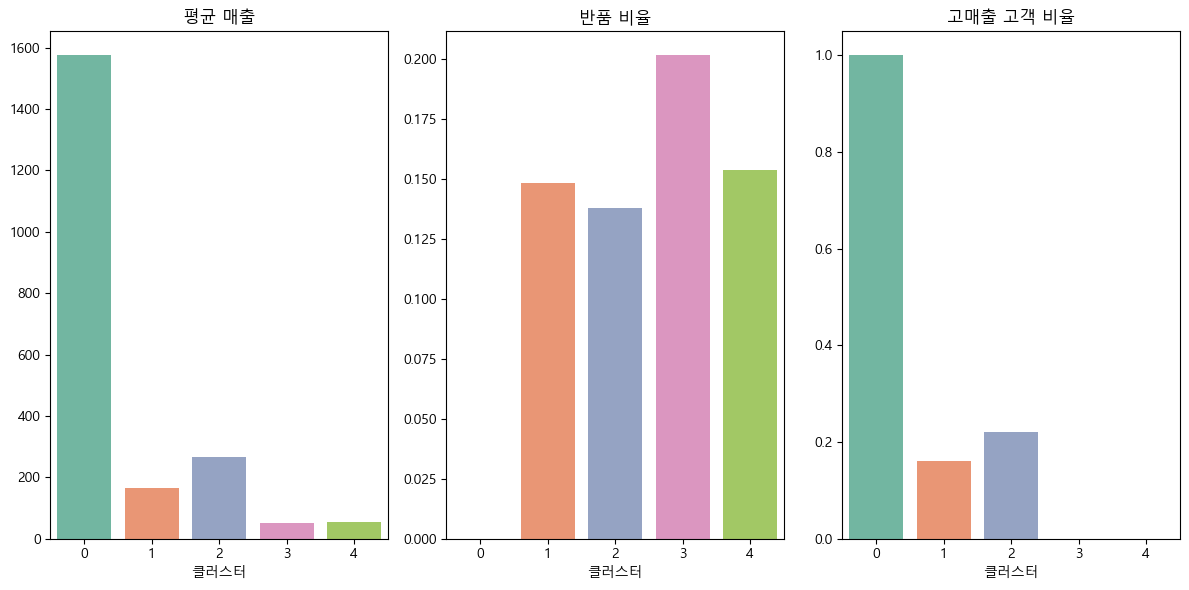

In [41]:
# 1. 클러스터별 주요 지표 시각화 막대그래프
import matplotlib.pyplot as plt
import seaborn as sns

# 클러스터별 요약 데이터프레임 생성
cluster_summary = df.groupby('MiniBatchKMeans_Cluster').agg({
    'sales': 'mean',
    'returned_amount': 'mean',
    'return_ratio': 'mean',
    'high_spender': 'mean',
    'duration_(secs)': 'mean',
    'membership': 'mean'
}).rename(columns={
    'sales': '평균 매출',
    'returned_amount': '평균 반품액',
    'return_ratio': '반품 비율',
    'high_spender': '고매출 고객 비율',
    'duration_(secs)': '평균 세션 시간',
    'membership': '평균 회원 등급'
}).reset_index()

# 📊 평균 매출, 반품 비율, 고매출 고객 비율 시각화
metrics = ['평균 매출', '반품 비율', '고매출 고객 비율']
plt.figure(figsize=(12, 6))
for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i+1)
    sns.barplot(data=cluster_summary, x='MiniBatchKMeans_Cluster', y=metric, palette='Set2')
    plt.title(metric)
    plt.xlabel("클러스터")
    plt.ylabel("")

plt.tight_layout()
plt.show()

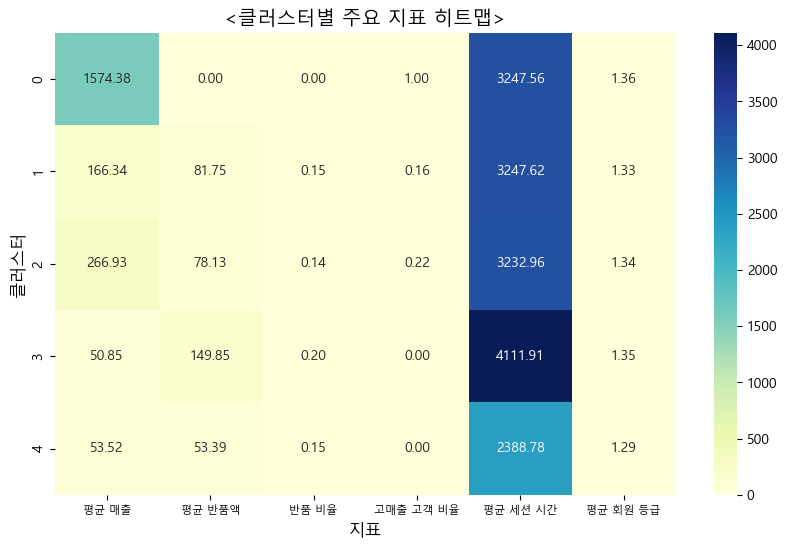

In [45]:
# 2. 클러스터별 주요 지표 히트맵
# 히트맵용 데이터 준비
heatmap_data = cluster_summary.set_index('MiniBatchKMeans_Cluster')

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("<클러스터별 주요 지표 히트맵>", fontsize=14)
plt.ylabel("클러스터", fontsize=12)
plt.xlabel("지표", fontsize=12)
plt.xticks(fontsize=8)

plt.show()

## 고객 세그먼트별 구매 예측 모델링

1. Logistic Regression (로지스틱 회귀)
  -  선형 모델로, 변수와 구매 여부 간의 선형적인 관계를 잘 설명할 수 있음
  - 모델이 간단하고 해석 가능성이 높음
  - 기준선 모델로 사용하기 적합하며, 다른 복잡한 모델의 성능을 비교하는 데 유용함
2. Random Forest (랜덤 포레스트)
  - 여러 결정 트리를 조합하여 과적합(Overfitting)을 방지하며 높은 정확도를 제공함
  - 변수 중요도를 제공해 주요 영향을 미치는 변수를 파악하는 데 유용
  - 다양한 데이터 구조에 적합하고, 비선형 관계를 잘 포착함
3. Gradient Boosting (그래디언트 부스팅)
  - 트리 기반 부스팅 모델로, 학습 오류를 단계적으로 줄여 성능을 개선함
  - 데이터에 비선형성과 복잡한 상호작용이 존재할 경우 효과적
  - 상대적으로 더 낮은 과적합 위험과 높은 예측 성능 제공
4. XGBoost (eXtreme Gradient Boosting)
  - Gradient Boosting의 확장판으로, 속도와 성능이 뛰어남
  - 정규화(Regularization) 기법으로 과적합 방지
  - 분류 문제뿐만 아니라 결측치 처리, 가중치 조정 등 다양한 기능 제공
5. LightGBM (Light Gradient Boosting Machine)
  - XGBoost와 유사하지만, 더 빠른 학습 속도와 낮은 메모리 사용량을 자랑함
  - 큰 데이터셋에 적합하며, 대규모 분류 작업에서도 효율적
  - 데이터의 분포에 따라 적응적으로 학습하며 복잡한 패턴을 잘 포착함

### 4개 모델링 시도 및 성능 평가

**목표로 잡을 수 있는 구체적 수치 (실무 가정 프로젝트 반영)**

1. **ROC-AUC 목표치**

    - Baseline(Logistic Regression 등): 약 0.85 전후

    - **목표: 0.90 이상**

    - Stretch 목표(실무 가정): 0.95 근접

    - 근거: Kaggle 데이터셋 자체가 깔끔해 baseline이 높게 나오므로, 실무 대비 보수적으로 0.90선을 “유효한 기준”으로 제시하면 설득력 있음.

2. **Precision 목표치**

    - Baseline: 0.85 전후

    - **목표: 0.90 이상**

    - Stretch 목표: 0.95 이상

    - 근거: Precision은 “비용 효율성”과 직결되므로, 90% 이상을 목표로 잡으면 마케팅 비용 절감 KPI와 연결 가능.

In [47]:
# 'sales' 변수를 기준으로 구매 여부를 생성 (0: 구매 없음, 1: 구매 있음)
df['purchase'] = (df['sales'] > 0).astype(int)

# 예측에 사용할 변수 선택
features  = [
    'duration_(secs)',
    'returned_amount',
    'membership',
    'device_desktop', 'device_mobile', 'device_other',
    'high_spender',
    'MiniBatchKMeans_Cluster' ## 클러스터
]
target = 'purchase'

# 학습/테스트 데이터 분리
from sklearn.model_selection import train_test_split

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [48]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 모델 리스트 정의
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}

# 결과 저장용 리스트
results = []

# 각 모델 학습 및 성능 평가
for model_name, model in models.items():
    print(f"\n🔹 Training {model_name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    })

# 결과 표로 출력
results_df = pd.DataFrame(results)
results_df.set_index("Model", inplace=True)
print("\n✅ 모델별 성능 비교")
display(results_df.round(4))  # 소수점 4자리


🔹 Training Logistic Regression...

🔹 Training Random Forest...

🔹 Training Gradient Boosting...

🔹 Training XGBoost...


C:\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:42:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



🔹 Training LightGBM...
[LightGBM] [Info] Number of positive: 105200, number of negative: 33070
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003334 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 138270, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.760830 -> initscore=1.157237
[LightGBM] [Info] Start training from score 1.157237

✅ 모델별 성능 비교


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.8914,0.8751,1.000,0.9334,0.8971
Random Forest,0.9797,0.9787,0.995,0.9868,0.9692
Gradient Boosting,0.9834,0.9787,1.000,0.9892,0.9785
XGBoost,0.9829,0.9780,1.000,0.9889,0.9777
LightGBM,0.9834,0.9787,1.000,0.9892,0.9783


- 4개 모델 모두에서 성능이 비정상적으로 높음 -> 과적합 의심.

### 성능 검증
- **교차검증 + 주요 피처 제거 + confusion matrix**

In [49]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 교차검증용 함수
def evaluate_model_cv(model, X, y, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=skf, scoring='roc_auc')
    print(f"💡 {model.__class__.__name__} 평균 ROC AUC (CV={cv}): {scores.mean():.4f} (+/- {scores.std():.4f})")
    return scores.mean()

# 2. 주요 피처 제거 후 성능 비교
def feature_drop_test(model, X, y, drop_features):
    X_new = X.drop(columns=drop_features)
    model.fit(X_new, y)
    score = cross_val_score(model, X_new, y, cv=5, scoring='roc_auc').mean()
    print(f"❌ {drop_features} 제거 후 ROC AUC: {score:.4f}")

# 3. Confusion Matrix & Classification Report
def plot_confusion_and_report(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # 시각화
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

    # classification report
    print("\n📄 Classification Report:")
    print(classification_report(y_test, y_pred))

[LightGBM] [Info] Number of positive: 84160, number of negative: 26456
[LightGBM] [Info] Total Bins 509
[LightGBM] [Info] Number of data points in the train set: 110616, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.760830 -> initscore=1.157237
[LightGBM] [Info] Start training from score 1.157237
[LightGBM] [Info] Number of positive: 84160, number of negative: 26456
[LightGBM] [Info] Total Bins 507
[LightGBM] [Info] Number of data points in the train set: 110616, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.760830 -> initscore=1.157237
[LightGBM] [Info] Start training from score 1.157237
[LightGBM] [Info] Number of positive: 84160, number of negative: 26456
[LightGBM] [Info] Total Bins 512
[LightGBM] [Info] Number of data points in the train set: 110616, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.760830 -> initscore=1.157237
[LightGBM] [Info] Start training from score 1.157237
[LightGBM] [I

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Info] Number of positive: 84160, number of negative: 26456
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002141 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 110616, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.760830 -> initscore=1.157237
[LightGBM] [Info] Start training from score 1.157237
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
❌ ['duration_(secs)'] 제거 후 ROC AUC: 0.9790
[LightGBM] [Info] Number of positive: 105200, number of negative: 33070
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002727 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 271
[LightGBM] [Info] Number of data points in the train set: 138270, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.760830 -> initscore=1.157237
[LightGBM] [Info] Start training from score 1.157237
[LightGBM] [Info] Number of positive: 84160, number of negative: 26456
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001780 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is n

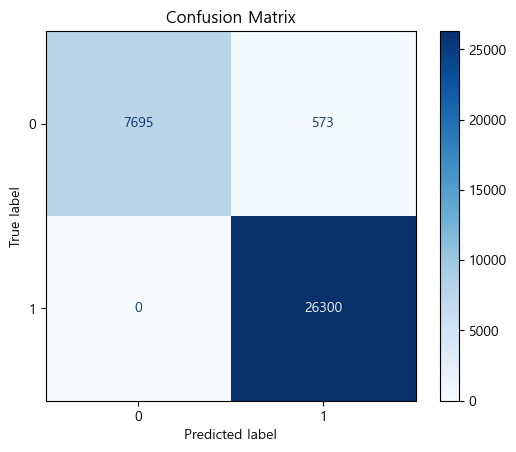


📄 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      8268
           1       0.98      1.00      0.99     26300

    accuracy                           0.98     34568
   macro avg       0.99      0.97      0.98     34568
weighted avg       0.98      0.98      0.98     34568



In [54]:
# 예시 실행 (LightGBM 기준)
from lightgbm import LGBMClassifier

# 전체 피처로 교차검증
lgb_model = LGBMClassifier(random_state=42, force_col_wise=True) # 메모리 절약을 위해 LightGBM 모델을 초기화
evaluate_model_cv(lgb_model, X_train, y_train)

# 주요 피처 제거 후 테스트
feature_drop_test(LGBMClassifier(random_state=42), X_train, y_train, drop_features=['duration_(secs)'])
feature_drop_test(LGBMClassifier(random_state=42), X_train, y_train, drop_features=['returned_amount'])
feature_drop_test(LGBMClassifier(random_state=42), X_train, y_train, drop_features=['high_spender'])

# 최종 모델 학습 후 Confusion Matrix & Report
final_model = LGBMClassifier(random_state=42)
final_model.fit(X_train, y_train)
plot_confusion_and_report(final_model, X_test, y_test)

- 단일 로우데이터로 클러스터링과 예측을 모두 진행했으나, 성능이 비정상적으로 높게 나와 과적합 의심.
-----------
- 이에 따라 train/test 분리 기준과 클러스터 정보 활용 방식에 대해 여러 실험을 설계해보고자 한다.

### 개선 시도
#### ✅ 1st) 클러스터링 train에만 적용 후 test에 레이블 예측

In [58]:
from sklearn.cluster import MiniBatchKMeans

# 1. 클러스터링에 사용할 변수 선택
cluster_features = [
    'duration_(secs)', 'returned_amount', 'membership',
    'device_desktop', 'device_mobile', 'device_other',
    'high_spender'
]

# 2. 클러스터링 모델 학습 (train 데이터만 사용)
kmeans = MiniBatchKMeans(n_clusters=5, random_state=42, batch_size=1024)
kmeans.fit(X_train[cluster_features])

# 3. 클러스터 레이블 생성
X_train['MiniBatchKMeans_Cluster'] = kmeans.predict(X_train[cluster_features])
X_test['MiniBatchKMeans_Cluster'] = kmeans.predict(X_test[cluster_features])

# 4. 예측용 feature 업데이트
features_with_cluster = cluster_features.copy()
features_with_cluster.append('MiniBatchKMeans_Cluster')

In [59]:
# 5. 모델 학습 및 예측 (예: LightGBM)
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = LGBMClassifier(random_state=42)
model.fit(X_train[features_with_cluster], y_train)

y_pred = model.predict(X_test[features_with_cluster])
y_proba = model.predict_proba(X_test[features_with_cluster])[:, 1]

# 6. 결과 평가
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Number of positive: 105200, number of negative: 33070
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002342 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 138270, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.760830 -> initscore=1.157237
[LightGBM] [Info] Start training from score 1.157237
ROC AUC: 0.9782
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      8268
           1       0.98      1.00      0.99     26300

    accuracy                           0.98     34568
   macro avg       0.99      0.97      0.98     34568
weighted avg       0.98      0.98      0.98     34568



#### ✅ 2nd) 로우 데이터 뒤쪽 20% 데이터를 최근 데이터처럼 간주
- 실제 비즈니스 환경에서는 최근 데이터만 따로 떼어내서 모델의 미래 예측력을 검증하는 것이 일반적이기 때문.

In [60]:
# 인덱스를 기준으로 의사 시계열 만들기
# 80%를 학습용, 20%를 테스트용으로 사용
split_idx = int(len(df) * 0.8)
df_train = df.iloc[:split_idx]
df_test = df.iloc[split_idx:]

In [61]:
# train/test 나눈 뒤 예측 모델 재학습 및 평가
X_train = df_train[features]
y_train = df_train['purchase']
X_test = df_test[features]
y_test = df_test['purchase']

# 모델 학습 및 평가
from lightgbm import LGBMClassifier
model = LGBMClassifier(random_state=42)
model.fit(X_train, y_train)

from sklearn.metrics import roc_auc_score, classification_report
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Number of positive: 102953, number of negative: 35317
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002375 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 507
[LightGBM] [Info] Number of data points in the train set: 138270, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.744579 -> initscore=1.069908
[LightGBM] [Info] Start training from score 1.069908
ROC AUC: 0.9527973422757274
              precision    recall  f1-score   support

           0       1.00      0.86      0.92      6021
           1       0.97      1.00      0.98     28547

    accuracy                           0.97     34568
   macro avg       0.99      0.93      0.95     34568
weighted avg       0.98      0.97      0.97     34568

